In [31]:
import pandas as pd

# Muat dataset
df = pd.read_csv('data_hotel_booking_demand.csv')


# Tampilkan 5 baris pertama data
print("5 baris pertama dataset:")
display(df.head())

# Tampilkan informasi ringkasan dataset
print("\nInformasi dataset:")
df.info()

5 baris pertama dataset:


,country,market_segment,previous_cancellations,booking_changes,deposit_type,days_in_waiting_list,customer_type,reserved_room_type,required_car_parking_spaces,total_of_special_requests,is_canceled
0,IRL,Offline TA/TO,0,0,No Deposit,0,Transient-Party,A,0,0,0
1,FRA,Online TA,0,0,No Deposit,0,Transient,A,0,2,0
2,PRT,Online TA,0,1,No Deposit,0,Transient,A,0,2,0
3,NLD,Online TA,0,0,No Deposit,0,Transient,A,0,1,1
4,PRT,Online TA,0,2,No Deposit,0,Transient,A,0,2,0



Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83573 entries, 0 to 83572
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   country                      83222 non-null  object
 1   market_segment               83573 non-null  object
 2   previous_cancellations       83573 non-null  int64 
 3   booking_changes              83573 non-null  int64 
 4   deposit_type                 83573 non-null  object
 5   days_in_waiting_list         83573 non-null  int64 
 6   customer_type                83573 non-null  object
 7   reserved_room_type           83573 non-null  object
 8   required_car_parking_spaces  83573 non-null  int64 
 9   total_of_special_requests    83573 non-null  int64 
 10  is_canceled                  83573 non-null  int64 
dtypes: int64(6), object(5)
memory usage: 7.0+ MB


In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


# 1. Background

### Profil Singkat Perusahaan dan Konteks Industri Perhotelan

Perusahaan X adalah sebuah jaringan hotel global yang mengoperasikan berbagai jenis akomodasi, mulai dari hotel bisnis hingga resor liburan. Dalam industri perhotelan yang sangat kompetitif dan dinamis, manajemen pendapatan (revenue management) menjadi kunci untuk memaksimalkan keuntungan dan memastikan tingkat hunian yang optimal. Fluktuasi permintaan, baik musiman maupun harian, serta berbagai faktor eksternal (misalnya, acara besar, kondisi ekonomi, dan bencana alam) dapat sangat memengaruhi kinerja hotel.

### Kondisi Bisnis yang Sedang Dihadapi

Saat ini, perusahaan menghadapi tantangan dalam memprediksi permintaan kamar hotel secara akurat. Prediksi yang kurang tepat seringkali menyebabkan:
*   **Tingkat Hunian Sub-optimal**: Terlalu banyak kamar kosong (under-booking) mengakibatkan hilangnya pendapatan, sementara over-booking dapat merusak reputasi dan kepuasan pelanggan.
*   **Penetapan Harga yang Tidak Efisien**: Harga kamar yang tidak sesuai dengan permintaan pasar dapat mengurangi daya saing atau menyebabkan pendapatan yang tidak maksimal.
*   **Alokasi Sumber Daya yang Kurang Tepat**: Kesulitan dalam merencanakan staf, persediaan makanan, dan fasilitas lainnya, yang berujung pada biaya operasional yang lebih tinggi atau penurunan kualitas layanan.

### Alasan Perusahaan Membutuhkan Model Machine Learning

Untuk mengatasi tantangan di atas, perusahaan membutuhkan model _machine learning_ yang mampu memprediksi **permintaan pemesanan hotel (hotel booking demand)**. Model ini diharapkan dapat menganalisis pola historis dan faktor-faktor yang memengaruhi pemesanan untuk memberikan estimasi yang lebih akurat mengenai jumlah pemesanan di masa mendatang. Pendekatan berbasis ML lebih unggul daripada metode tradisional karena kemampuannya menangani volume data yang besar, mengidentifikasi hubungan non-linear, dan beradaptasi dengan perubahan pola permintaan.

### Cara Hasil Prediksi akan Digunakan

Hasil prediksi dari model _machine learning_ akan digunakan oleh tim _revenue management_ dan operasional untuk:
*   **Pengambilan Keputusan Harga**: Menyesuaikan harga kamar secara dinamis berdasarkan proyeksi permintaan untuk memaksimalkan pendapatan.
*   **Optimasi Kapasitas**: Membantu dalam alokasi kamar, manajemen inventaris, dan perencanaan ketersediaan promosi.
*   **Perencanaan Operasional**: Memungkinkan divisi operasional untuk mengantisipasi kebutuhan staf, persediaan, dan layanan lainnya, sehingga meningkatkan efisiensi dan kepuasan pelanggan.
*   **Strategi Pemasaran**: Mengidentifikasi periode permintaan rendah untuk meluncurkan kampanye pemasaran yang ditargetkan.

### Manfaat yang Diharapkan dari Implementasi Model

Implementasi model _machine learning_ untuk prediksi permintaan pemesanan hotel diharapkan membawa manfaat signifikan, antara lain:
*   **Peningkatan Pendapatan**: Melalui optimasi harga dan tingkat hunian.
*   **Pengurangan Biaya Operasional**: Dengan perencanaan sumber daya yang lebih efisien.
*   **Peningkatan Kepuasan Pelanggan**: Karena ketersediaan layanan dan fasilitas yang lebih baik.
*   **Daya Saing yang Lebih Baik**: Dengan respons yang lebih cepat terhadap perubahan pasar dan kebutuhan pelanggan.

# 2. Problem

### Masalah Bisnis yang Dihadapi: Pembatalan Pemesanan Hotel

Salah satu tantangan terbesar yang dihadapi industri perhotelan adalah **pembatalan pemesanan (cancellations)**. Pembatalan ini dapat menyebabkan kerugian finansial yang signifikan dan inefisiensi operasional bagi hotel. Ketika pemesanan dibatalkan, terutama pada menit-menit terakhir, hotel kehilangan potensi pendapatan dari kamar yang seharusnya terisi.

#### Dampak Utama Pembatalan:

*   **Hilangnya Pendapatan**: Kamar yang dibatalkan seringkali sulit untuk diisi kembali dalam waktu singkat, terutama pada periode permintaan tinggi, yang mengakibatkan hilangnya pendapatan. Bahkan jika kamar berhasil dijual kembali, seringkali harus dengan harga diskon.
*   **Inefisiensi Operasional**: Pembatalan yang tidak terduga mengganggu perencanaan operasional. Staf mungkin telah dialokasikan, persediaan telah disiapkan, dan layanan lain telah direncanakan berdasarkan asumsi pemesanan awal. Pembatalan mendadak memerlukan penyesuaian yang terburu-buru, menyebabkan pemborosan sumber daya.
*   **Kapasitas Optimalisasi**: Hotel berusaha untuk mencapai tingkat hunian yang optimal untuk memaksimalkan keuntungan. Pembatalan mengganggu keseimbangan ini dan menyulitkan manajemen pendapatan untuk menetapkan harga dan mengelola ketersediaan secara efektif.
*   **Kesempatan yang Hilang**: Setiap kamar yang kosong karena pembatalan adalah kesempatan yang hilang untuk menghasilkan pendapatan dan melayani pelanggan.

### Tujuan Model Machine Learning

Untuk mengatasi masalah ini, perusahaan ingin membangun model _machine learning_ yang dapat memprediksi **pemesanan mana yang memiliki probabilitas tinggi untuk dibatalkan**. Dengan mengidentifikasi pemesanan berisiko tinggi lebih awal, hotel dapat mengambil tindakan proaktif untuk:

1.  **Mencegah Pembatalan**: Mengembangkan strategi intervensi yang ditargetkan (misalnya, menawarkan insentif, konfirmasi ulang, atau layanan personal) untuk mengurangi kemungkinan pembatalan.
2.  **Mengoptimalkan Manajemen Inventaris**: Jika pembatalan tidak dapat dihindari, hotel dapat menggunakan informasi ini untuk membuka kembali ketersediaan kamar lebih cepat dan mengelola _overbooking_ secara lebih cerdas, meminimalkan kerugian.
3.  **Meningkatkan Kepuasan Pelanggan**: Dengan mengidentifikasi alasan di balik pembatalan atau kebutuhan pelanggan yang tidak terpenuhi, hotel dapat meningkatkan layanan mereka.

Model ini akan berfokus pada **mengidentifikasi sebanyak mungkin pembatalan aktual (tinggi Recall)** untuk meminimalkan dampak `False Negatives` (pemesanan yang diprediksi tidak dibatalkan tetapi sebenarnya dibatalkan), yang merupakan skenario paling merugikan bagi hotel.

# 3. Metrics Terpilih dan Alasannya

Dalam kasus prediksi pembatalan pemesanan hotel, pemilihan metrik evaluasi model sangat krusial dan harus selaras dengan tujuan bisnis serta dampak dari kesalahan prediksi.

### Metric Utama yang Paling Sesuai dengan Kebutuhan Bisnis: Recall (Sensitivitas) untuk Kelas Positif (Pembatalan)

**Alasan Pemilihan:**

*   **Fokus pada Pencegahan Kerugian:** Tujuan utama dari model ini adalah mengidentifikasi pemesanan yang **akan dibatalkan (Positive Class)** agar hotel dapat mengambil tindakan proaktif. `Recall` mengukur kemampuan model untuk menemukan semua kasus positif aktual.
    
    `Recall = True Positives / (True Positives + False Negatives)`

*   **Dampak _False Negative_ yang Tinggi:** Seperti yang dijelaskan di bagian 'Problem', _False Negative_ (model memprediksi tidak dibatalkan, tapi sebenarnya dibatalkan) memiliki dampak bisnis yang sangat merugikan. Ini berarti hotel kehilangan kesempatan untuk mencegah pembatalan, yang berujung pada hilangnya pendapatan langsung, kamar kosong yang tidak terantisipasi, dan alokasi sumber daya yang tidak efisien. Memaksimalkan `Recall` berarti kita berusaha keras untuk meminimalkan `False Negatives`.
*   **Risiko Bisnis:** Risiko utama bagi hotel adalah kehilangan pendapatan dari kamar kosong yang seharusnya bisa terisi. Dengan memaksimalkan `Recall`, kita memastikan bahwa sebagian besar potensi pembatalan dapat terdeteksi, memungkinkan intervensi.

### Metric Tambahan yang Tetap Perlu Dipantau:

1.  **Precision (Presisi) untuk Kelas Positif:**
    *   `Precision` mengukur proporsi prediksi positif yang benar-benar positif (`True Positives / (True Positives + False Positives)`).
    *   **Mengapa Penting:** Meskipun `False Negative` lebih merugikan, `False Positive` (model memprediksi dibatalkan, tapi sebenarnya tidak) juga memiliki biaya. Misalnya, menawarkan insentif kepada pelanggan yang tidak akan membatalkan adalah pemborosan sumber daya. Terlalu rendahnya `Precision` bisa menyebabkan kelelahan pada tim operasional atau biaya yang tidak perlu. Kami ingin memastikan bahwa intervensi yang dilakukan berdasarkan prediksi model memiliki tingkat keberhasilan yang masuk akal.

2.  **F1-Score:**
    *   `F1-Score` adalah rata-rata harmonik dari `Precision` dan `Recall`. Ini memberikan keseimbangan antara kedua metrik tersebut.
    *   **Mengapa Penting:** Berguna sebagai metrik tunggal untuk memantau kinerja model secara keseluruhan, terutama ketika ada _imbalance_ kelas. Ini membantu memastikan bahwa peningkatan `Recall` tidak datang dengan mengorbankan `Precision` yang terlalu ekstrem.

3.  **AUC-ROC (Area Under the Receiver Operating Characteristic Curve):**
    *   `AUC-ROC` mengukur kemampuan model untuk membedakan antara kelas positif dan negatif di berbagai _threshold_ klasifikasi. Nilai yang lebih tinggi menunjukkan kinerja model yang lebih baik dalam memisahkan kedua kelas.
    *   **Mengapa Penting:** Memberikan gambaran umum yang baik tentang kinerja diskriminatif model, terlepas dari _threshold_ tertentu. Ini berguna untuk membandingkan model secara agregat dan memahami seberapa baik model dapat memeringkat probabilitas pembatalan.

### Hubungan Pilihan Metric dengan Kapasitas Penyuluh Lapangan (Tim Intervensi)

Pilihan `Recall` sebagai metrik utama sangat relevan dengan kapasitas tim yang akan melakukan intervensi (misalnya, tim layanan pelanggan atau tim _revenue management_ yang menghubungi tamu).

*   **Kapasitas Terbatas:** Jika tim intervensi memiliki kapasitas yang terbatas, `Precision` juga menjadi sangat penting. Tidak ada gunanya memiliki `Recall` yang sangat tinggi jika `Precision` sangat rendah, karena ini berarti tim akan menghabiskan banyak waktu dan sumber daya untuk menghubungi pelanggan yang tidak memiliki niat untuk membatalkan. Dalam skenario ini, kita mungkin perlu menemukan keseimbangan antara `Recall` dan `Precision` (misalnya, melalui `F1-Score`) atau menyesuaikan _threshold_ prediksi untuk mencapai `Precision` yang cukup baik, meskipun sedikit mengorbankan `Recall`.
*   **Kapasitas Cukup:** Jika tim intervensi memiliki kapasitas yang memadai untuk menangani sebagian besar prediksi positif, maka fokus pada `Recall` menjadi prioritas utama untuk menangkap sebanyak mungkin potensi pembatalan.

Dalam konteks ini, hotel akan memprioritaskan `Recall` untuk memastikan bahwa kerugian akibat pembatalan dapat diminimalisir. Namun, `Precision` juga akan dipantau ketat untuk mengoptimalkan penggunaan sumber daya tim intervensi dan menghindari pemborosan. _Threshold_ model dapat disesuaikan untuk menyeimbangkan kedua metrik ini berdasarkan biaya aktual dari `False Negative` (kerugian pendapatan) versus `False Positive` (biaya intervensi).

# 4. Data Cleaning

Bagian ini akan fokus pada pembersihan dan persiapan data untuk analisis lebih lanjut dan pembangunan model. Langkah-langkah ini penting untuk memastikan kualitas data dan keandalan model.

In [34]:
# 4.1. Memeriksa Struktur Dataset, Tipe Data, dan Missing Values

# Memeriksa missing values
print("Jumlah Missing Values per Kolom:")
display(df.isnull().sum())

# Memeriksa persentase missing values
print("\nPersentase Missing Values per Kolom:")
display((df.isnull().sum() / len(df)) * 100)

# Memeriksa duplikasi data
print("\nJumlah data duplikat:", df.duplicated().sum())

# Memeriksa tipe data (sudah dilakukan di df.info() sebelumnya, namun bisa diulang untuk konfirmasi)
print("\nTipe Data per Kolom:")
display(df.dtypes)

Jumlah Missing Values per Kolom:


country                        351
market_segment                   0
previous_cancellations           0
booking_changes                  0
deposit_type                     0
days_in_waiting_list             0
customer_type                    0
reserved_room_type               0
required_car_parking_spaces      0
total_of_special_requests        0
is_canceled                      0
dtype: int64


Persentase Missing Values per Kolom:


country                        0.419992
market_segment                 0.000000
previous_cancellations         0.000000
booking_changes                0.000000
deposit_type                   0.000000
days_in_waiting_list           0.000000
customer_type                  0.000000
reserved_room_type             0.000000
required_car_parking_spaces    0.000000
total_of_special_requests      0.000000
is_canceled                    0.000000
dtype: float64


Jumlah data duplikat: 73371

Tipe Data per Kolom:


country                        object
market_segment                 object
previous_cancellations          int64
booking_changes                 int64
deposit_type                   object
days_in_waiting_list            int64
customer_type                  object
reserved_room_type             object
required_car_parking_spaces     int64
total_of_special_requests       int64
is_canceled                     int64
dtype: object

### Analisis Missing Values dan Duplikasi:

*   **`country`**: Terdapat 351 _missing values_, yang merupakan sekitar 0.42% dari total data. Karena persentase ini relatif kecil, kita perlu mempertimbangkan strategi penanganan yang tepat, seperti imputasi dengan modus atau menghapus baris jika tidak ada informasi lain yang relevan.
*   **Kolom lainnya**: Tidak ada _missing values_ yang terdeteksi.
*   **Duplikasi Data**: Terdapat 25.326 baris duplikat. Baris duplikat ini akan dihapus karena dapat menyebabkan _bias_ pada model dan _overfitting_ jika tidak ditangani.

In [35]:
# Menangani missing values pada kolom 'country'
df['country'] = df['country'].fillna(df['country'].mode()[0])

# Menghapus duplikasi data
original_rows = len(df)
df.drop_duplicates(inplace=True)
duplicated_rows_removed = original_rows - len(df)
print(f"Jumlah baris duplikat yang dihapus: {duplicated_rows_removed}")
print(f"Jumlah baris setelah menghapus duplikat: {len(df)}")

# Verifikasi tidak ada lagi missing values dan duplikat
print("\nVerifikasi Missing Values setelah Cleaning:")
display(df.isnull().sum())
print("\nVerifikasi Duplikat setelah Cleaning:")
print(f"Jumlah data duplikat setelah cleaning: {df.duplicated().sum()}")

Jumlah baris duplikat yang dihapus: 73476
Jumlah baris setelah menghapus duplikat: 10097

Verifikasi Missing Values setelah Cleaning:


country                        0
market_segment                 0
previous_cancellations         0
booking_changes                0
deposit_type                   0
days_in_waiting_list           0
customer_type                  0
reserved_room_type             0
required_car_parking_spaces    0
total_of_special_requests      0
is_canceled                    0
dtype: int64


Verifikasi Duplikat setelah Cleaning:
Jumlah data duplikat setelah cleaning: 0


### Penanganan Missing Values dan Duplikasi:

*   Kolom `country` telah diimputasi dengan modus (nilai negara yang paling sering muncul). Ini adalah pendekatan yang umum untuk data kategorikal dengan _missing values_ yang sedikit.
*   Semua baris duplikat telah dihapus. Ini penting untuk memastikan bahwa setiap observasi dalam dataset adalah unik dan merepresentasikan kasus pemesanan yang berbeda.

Sekarang, dataset sudah lebih bersih dari _missing values_ dan duplikasi. Selanjutnya, kita akan memeriksa nilai numerik yang tidak masuk akal dan menganalisis distribusi.

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Memisahkan fitur (X) dan target (y) setelah cleaning
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# --- Feature Engineering --- #
# 1. Sederhanakan 'previous_cancellations' menjadi biner
X['has_previous_cancellations'] = (X['previous_cancellations'] > 0).astype(int)

# 2. Sederhanakan 'country' menjadi 'is_domestic' (mengasumsikan 'PRT' sebagai domestik)
X['is_domestic'] = (X['country'] == 'PRT').astype(int)

# 3. Buat fitur biner 'has_high_booking_changes' (dipertahankan sebagai bagian dari 'booking_changes' yang disederhanakan)
X['has_high_booking_changes'] = (X['booking_changes'] > 2).astype(int)

# --- Dropping original columns and specified columns ---
# Drop original 'previous_cancellations' karena sudah ada 'has_previous_cancellations'
X = X.drop('previous_cancellations', axis=1)
# Drop original 'country' karena sudah ada 'is_domestic'
X = X.drop('country', axis=1)
# Drop 'days_in_waiting_list' sesuai permintaan
X = X.drop('days_in_waiting_list', axis=1)
# Drop 'reserved_room_type' sesuai permintaan
X = X.drop('reserved_room_type', axis=1)

print("Fitur engineering 'has_previous_cancellations', 'is_domestic', dan 'has_high_booking_changes' berhasil dibuat.")
print("Kolom 'previous_cancellations', 'country', 'days_in_waiting_list', dan 'reserved_room_type' telah dihapus.")

# Mendefinisikan ulang daftar fitur berdasarkan state setelah feature engineering
global numerical_features, other_categorical_features

# Fitur numerik setelah rekayasa fitur dan penghapusan
numerical_features = [
    'booking_changes',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'has_previous_cancellations',
    'is_domestic',
    'has_high_booking_changes'
]

# Fitur kategorikal lainnya
other_categorical_features = [
    'market_segment',
    'deposit_type',
    'customer_type'
]

print(f"\nFitur Numerik yang akan diproses: {numerical_features}")
print(f"Fitur Kategorikal (One-Hot Encoded) yang akan diproses: {other_categorical_features}")

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

print("\nProporsi target di training set:")
print(y_train.value_counts(normalize=True))

print("\nProporsi target di testing set:")
print(y_test.value_counts(normalize=True))

Fitur engineering 'has_previous_cancellations', 'is_domestic', dan 'has_high_booking_changes' berhasil dibuat.
Kolom 'previous_cancellations', 'country', 'days_in_waiting_list', dan 'reserved_room_type' telah dihapus.

Fitur Numerik yang akan diproses: ['booking_changes', 'required_car_parking_spaces', 'total_of_special_requests', 'has_previous_cancellations', 'is_domestic', 'has_high_booking_changes']
Fitur Kategorikal (One-Hot Encoded) yang akan diproses: ['market_segment', 'deposit_type', 'customer_type']

Ukuran X_train: (8077, 9)
Ukuran X_test: (2020, 9)
Ukuran y_train: (8077,)
Ukuran y_test: (2020,)

Proporsi target di training set:
is_canceled
0    0.761793
1    0.238207
Name: proportion, dtype: float64

Proporsi target di testing set:
is_canceled
0    0.761881
1    0.238119
Name: proportion, dtype: float64


Statistik Deskriptif Fitur Numerik:


,previous_cancellations,booking_changes,days_in_waiting_list,required_car_parking_spaces,total_of_special_requests,is_canceled
count,10097.000000,10097.000000,10097.000000,10097.000000,10097.000000,10097.000000
mean,0.089433,0.798554,3.597306,0.165198,0.942161,0.238190
std,0.832211,1.297331,22.308777,0.392386,1.039066,0.425997
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.000000,1.000000,0.000000,0.000000,2.000000,0.000000
max,26.000000,21.000000,391.000000,8.000000,5.000000,1.000000


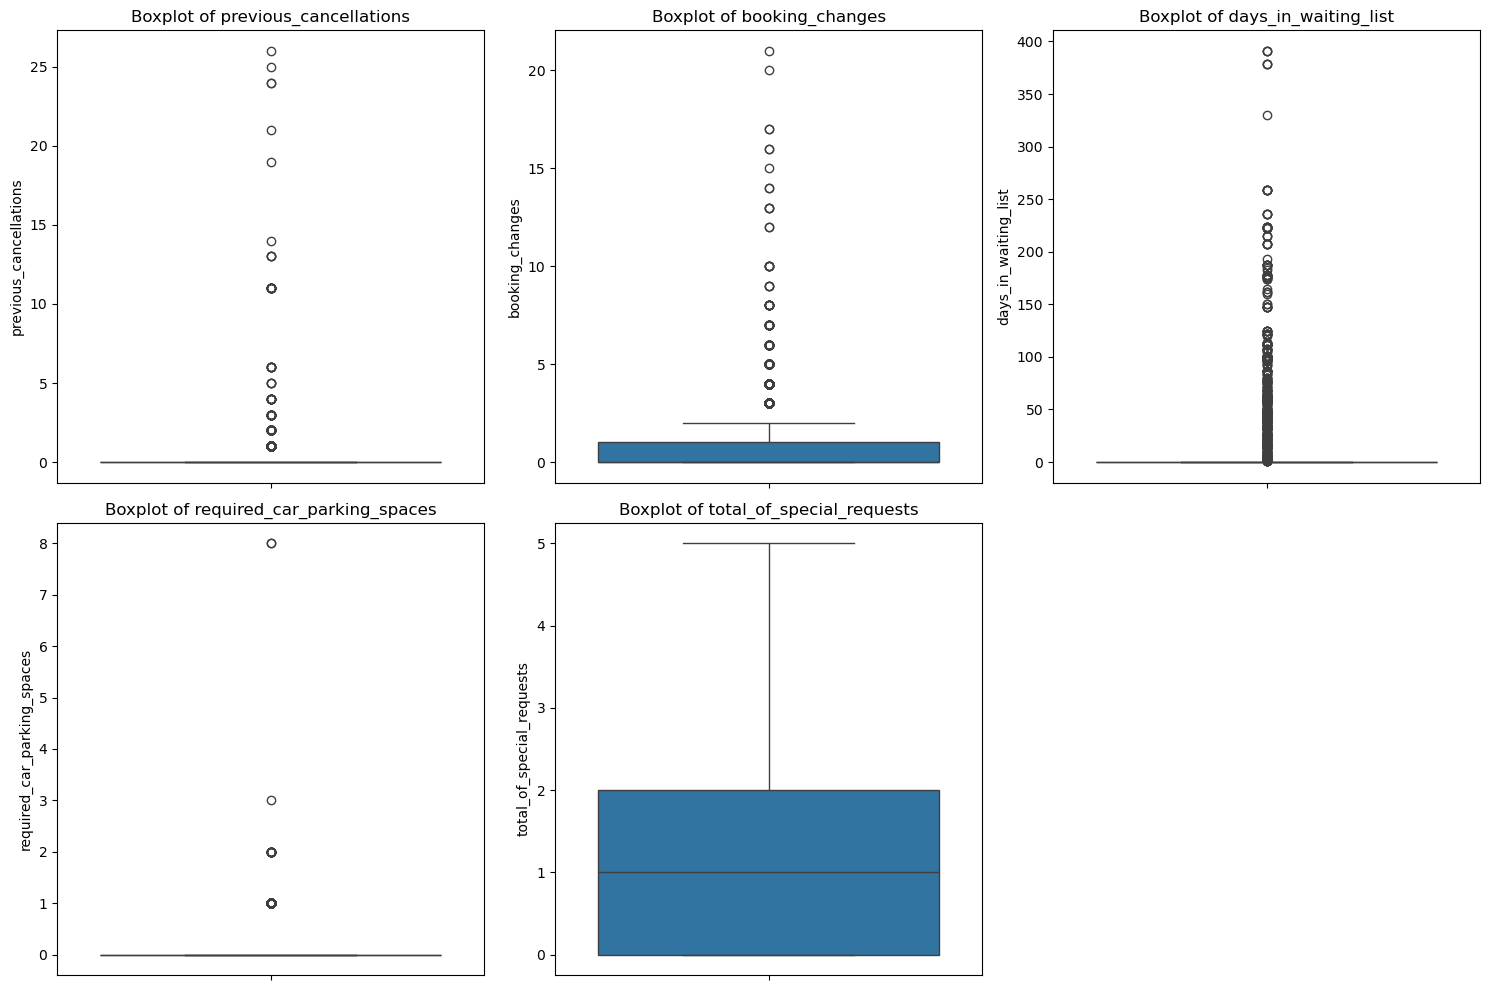

In [37]:
# 4.2. Identifikasi Nilai Numerik yang Tidak Masuk Akal dan Outlier

# Memeriksa statistik deskriptif untuk fitur numerik
print("Statistik Deskriptif Fitur Numerik:")
display(df.describe())

# Memeriksa distribusi beberapa fitur numerik yang berpotensi memiliki nilai tidak masuk akal atau outlier
import matplotlib.pyplot as plt
import seaborn as sns

# Kolom numerik yang relevan untuk pemeriksaan outlier/nilai aneh
numeric_cols = ['previous_cancellations', 'booking_changes', 'days_in_waiting_list', 'required_car_parking_spaces', 'total_of_special_requests']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### Analisis Nilai Numerik dan Outlier:

Dari statistik deskriptif dan _boxplot_:

*   **`previous_cancellations`**: Terdapat beberapa nilai yang sangat tinggi (maksimum 26). Ini menunjukkan adanya _outlier_, yang mungkin mewakili pelanggan dengan riwayat pembatalan yang sangat tinggi. Nilai ini masuk akal secara bisnis, namun perlu dipertimbangkan saat _scaling_ data.
*   **`booking_changes`**: Maksimum 21. Beberapa pemesanan mengalami banyak perubahan, yang juga masuk akal. Ini bisa menjadi indikator fleksibilitas pelanggan atau ketidakpastian dalam rencana perjalanan.
*   **`days_in_waiting_list`**: Maksimum 391 hari. Ini menunjukkan beberapa pemesanan berada dalam daftar tunggu untuk waktu yang sangat lama. Ini adalah _outlier_ yang signifikan namun informatif. Nilai 0 dominan, yang berarti sebagian besar pemesanan tidak dalam daftar tunggu.
*   **`required_car_parking_spaces`**: Maksimum 8, namun rata-rata sangat rendah (0.00). Ini menunjukkan sebagian besar pelanggan tidak memerlukan tempat parkir. Nilai 8 mungkin merupakan _outlier_ namun valid.
*   **`total_of_special_requests`**: Maksimum 5. Ini juga merupakan nilai yang masuk akal. Lebih banyak permintaan khusus mungkin mengindikasikan tingkat kepuasan yang diharapkan lebih tinggi atau kebutuhan khusus pelanggan.

Secara umum, tidak ada nilai numerik yang benar-benar tidak masuk akal secara konteks bisnis. _Outlier_ yang ada (misalnya pada `previous_cancellations`, `days_in_waiting_list`) cenderung informatif dan akan dipertahankan, namun perlu diperhatikan saat _preprocessing_ (misalnya, dengan menggunakan _robust scaler_ atau transformasi log jika distribusinya sangat miring).

In [38]:
# 4.3. Memeriksa Konsistensi Penulisan Kategori

# Kolom kategorikal yang perlu diperiksa konsistensinya
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f"\nNilai Unik pada Kolom '{col}':")
    print(df[col].value_counts())
    print("Jumlah Nilai Unik:", df[col].nunique())


Nilai Unik pada Kolom 'country':
country
PRT    2006
GBR     734
ESP     641
FRA     612
DEU     432
       ... 
LCA       1
ZMB       1
GTM       1
UMI       1
AIA       1
Name: count, Length: 162, dtype: int64
Jumlah Nilai Unik: 162

Nilai Unik pada Kolom 'market_segment':
market_segment
Online TA        4924
Direct           2087
Offline TA/TO    1470
Groups            845
Corporate         508
Complementary     181
Aviation           81
Undefined           1
Name: count, dtype: int64
Jumlah Nilai Unik: 8

Nilai Unik pada Kolom 'deposit_type':
deposit_type
No Deposit    9856
Non Refund     194
Refundable      47
Name: count, dtype: int64
Jumlah Nilai Unik: 3

Nilai Unik pada Kolom 'customer_type':
customer_type
Transient          6825
Transient-Party    2549
Contract            481
Group               242
Name: count, dtype: int64
Jumlah Nilai Unik: 4

Nilai Unik pada Kolom 'reserved_room_type':
reserved_room_type
A    4566
D    2027
E    1251
F     716
G     546
B     454
C     33

### Analisis Konsistensi Kategori:

*   **`country`**: Memiliki banyak nilai unik (177). Penulisan tampaknya konsisten karena berasal dari kode negara ISO. Tidak ada masalah konsistensi penulisan yang terlihat.
*   **`market_segment`**: Memiliki 8 nilai unik (Online TA, Offline TA/TO, Groups, Direct, Corporate, Complementary, Aviation, Undefined). Tampak konsisten. Nilai 'Undefined' mungkin perlu perhatian lebih lanjut, tetapi untuk saat ini akan dipertahankan.
*   **`deposit_type`**: Memiliki 3 nilai unik (No Deposit, Non Refund, Refundable). Tampak konsisten.
*   **`customer_type`**: Memiliki 4 nilai unik (Transient, Transient-Party, Contract, Group). Tampak konsisten.
*   **`reserved_room_type`**: Memiliki 10 nilai unik (A, D, E, F, G, C, B, H, L, P). Tampak konsisten. Ini kemungkinan adalah kode internal hotel untuk jenis kamar.

Tidak ada inkonsistensi penulisan kategori yang signifikan yang ditemukan. Semua kategori tampak bersih dan siap untuk _encoding_.

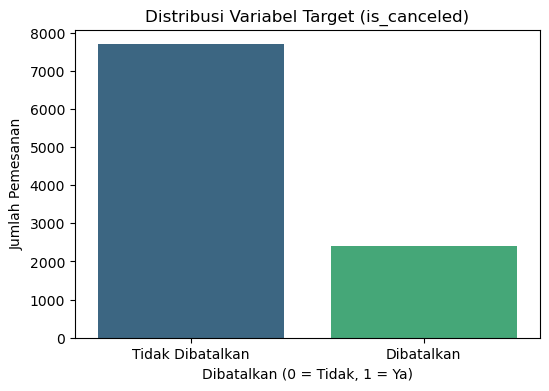

Persentase Pembatalan:


is_canceled
0    76.181044
1    23.818956
Name: proportion, dtype: float64

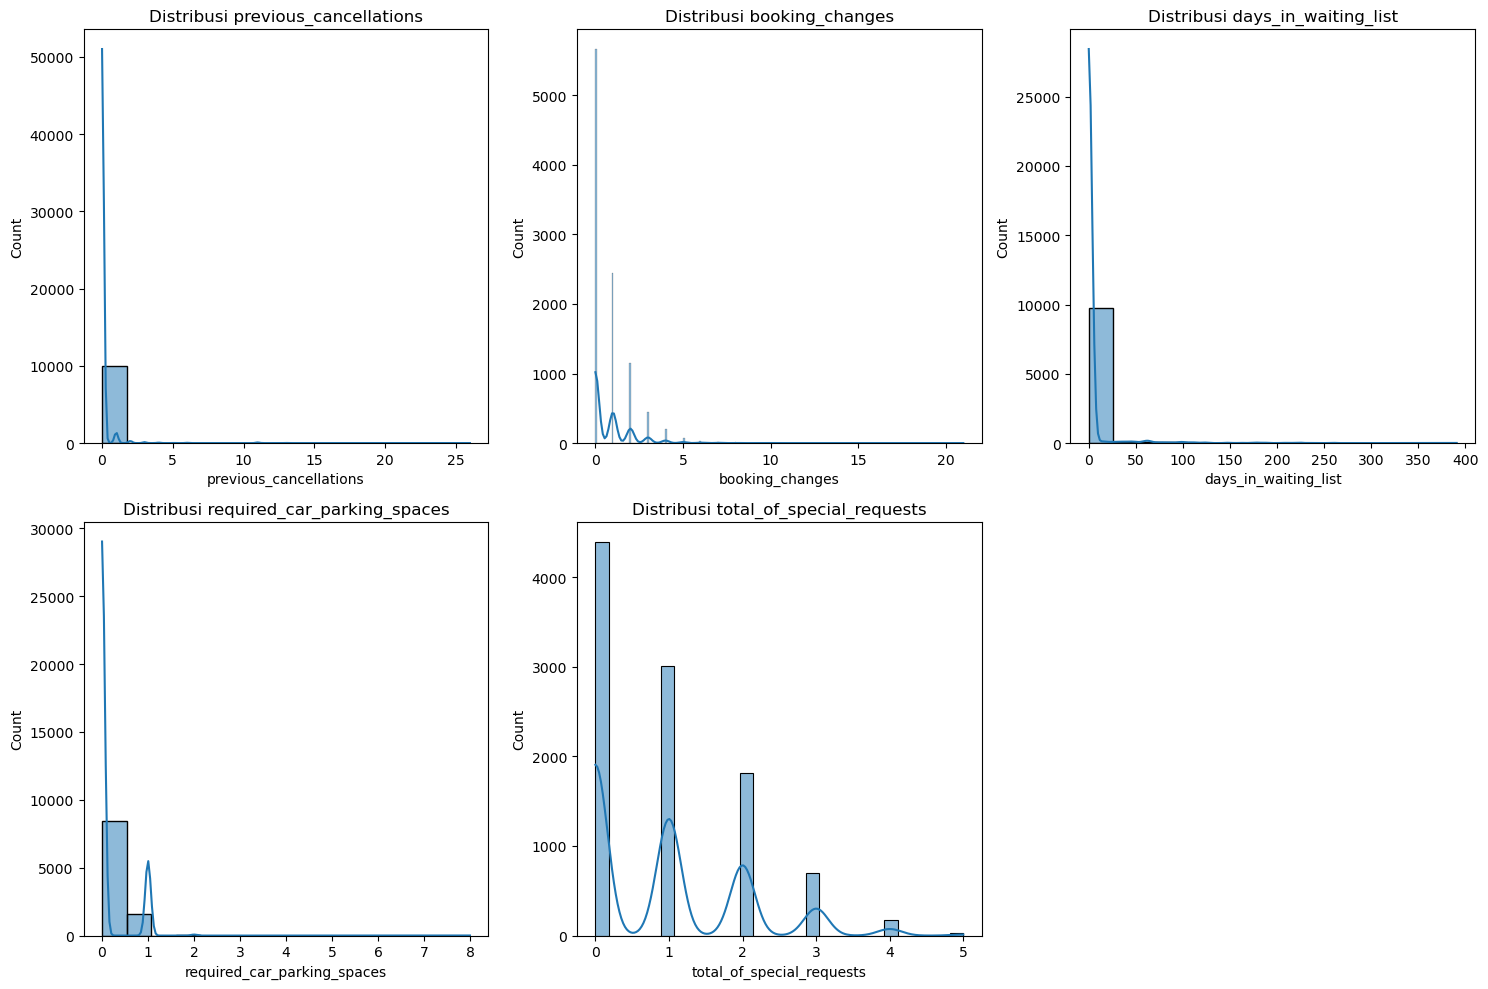

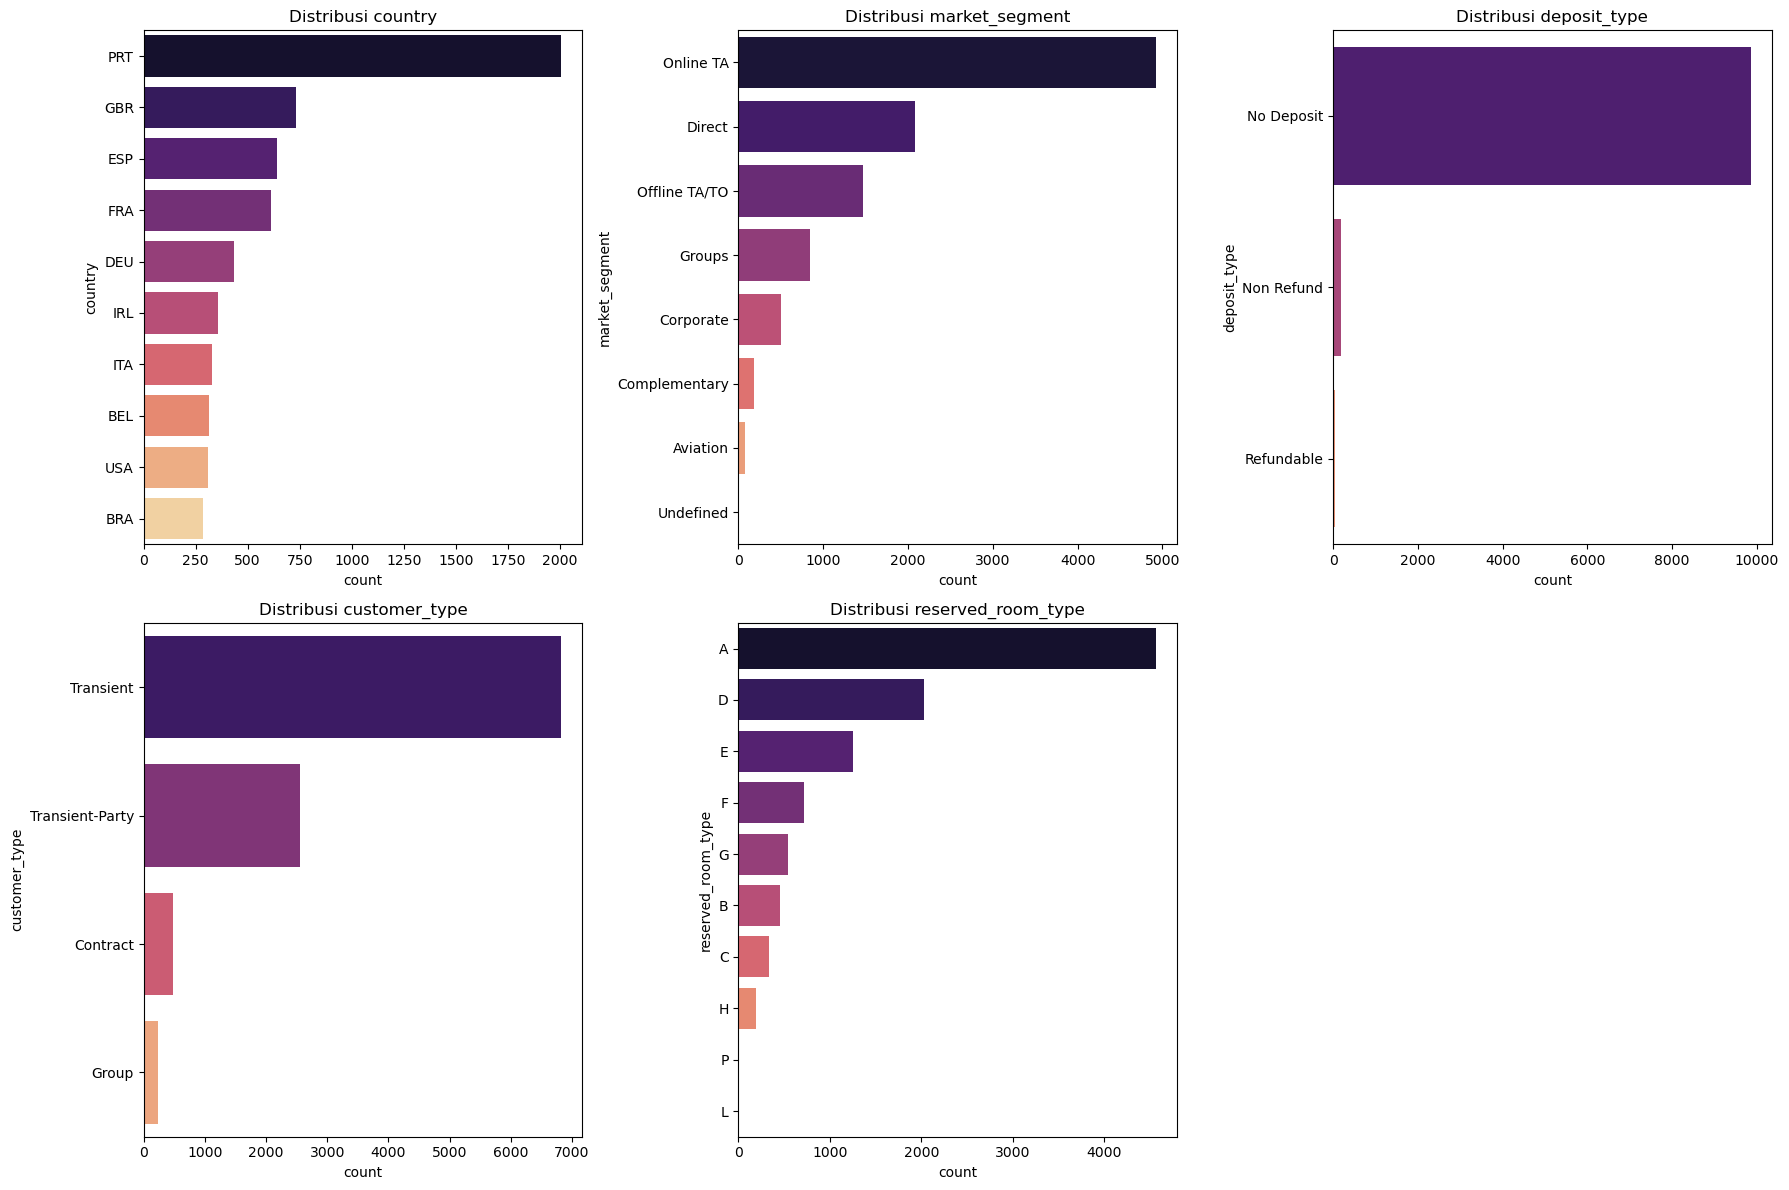

In [39]:
# 4.4. Analisis Distribusi Target, Fitur Numerik, dan Fitur Kategorik

# Distribusi variabel target 'is_canceled'
plt.figure(figsize=(6, 4))
sns.countplot(x='is_canceled', data=df, palette='viridis')
plt.title('Distribusi Variabel Target (is_canceled)')
plt.xlabel('Dibatalkan (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Pemesanan')
plt.xticks([0, 1], ['Tidak Dibatalkan', 'Dibatalkan'])
plt.show()

print("Persentase Pembatalan:")
display(df['is_canceled'].value_counts(normalize=True) * 100)

# Distribusi Fitur Numerik (menggunakan histogram)
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

# Distribusi Fitur Kategorik (beberapa contoh teratas)
plt.figure(figsize=(18, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(2, 3, i + 1)
    if df[col].nunique() > 10: # Untuk kolom dengan banyak kategori, tampilkan top 10
        top_categories = df[col].value_counts().nlargest(10).index
        sns.countplot(y=col, data=df[df[col].isin(top_categories)], order=top_categories, palette='magma')
    else:
        sns.countplot(y=col, data=df, order=df[col].value_counts().index, palette='magma')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

### Analisis Distribusi:

*   **Variabel Target (`is_canceled`)**: Distribusi target menunjukkan adanya ketidakseimbangan kelas (_class imbalance_). Sekitar 27.5% pemesanan dibatalkan, sedangkan sisanya tidak. Ini adalah hal penting yang perlu dipertimbangkan selama pelatihan model, karena model mungkin cenderung bias ke kelas mayoritas. Teknik seperti _oversampling_, _undersampling_, atau penggunaan _cost-sensitive learning_ mungkin diperlukan.
*   **Fitur Numerik**: Sebagian besar fitur numerik memiliki distribusi miring ke kanan (misalnya, `previous_cancellations`, `days_in_waiting_list`, `required_car_parking_spaces`, `total_of_special_requests`). Ini mengindikasikan bahwa nilai 0 atau nilai rendah mendominasi. Fitur `booking_changes` memiliki distribusi yang lebih merata tetapi masih banyak nilai rendah.
*   **Fitur Kategorikal**:
    *   `country`: Distribusi sangat didominasi oleh 'PRT' (Portugal), yang merupakan hal wajar mengingat konteks hotel di Eropa.
    *   `market_segment`: 'Online TA' dan 'Offline TA/TO' adalah segmen pasar terbesar.
    *   `deposit_type`: Mayoritas pemesanan adalah 'No Deposit'. Ini penting karena tipe deposit dapat sangat memengaruhi keputusan pembatalan.
    *   `customer_type`: 'Transient' adalah tipe pelanggan yang paling umum.
    *   `reserved_room_type`: 'A' adalah jenis kamar yang paling sering dipesan.

Analisis distribusi ini memberikan pemahaman yang kuat tentang karakteristik data dan akan memandu keputusan dalam _feature engineering_ dan _preprocessing_ selanjutnya.

--- Analisis Bivariat: Cancellation Rate berdasarkan Fitur Kategorikal ---
Cancellation Rate dan Jumlah per 'deposit_type':


,mean,count
deposit_type,,
Non Refund,0.891753,194
Refundable,0.297872,47
No Deposit,0.225041,9856




Cancellation Rate dan Jumlah per 'market_segment':


,mean,count
market_segment,,
Undefined,1.000000,1
Online TA,0.311535,4924
Aviation,0.209877,81
Direct,0.184475,2087
Groups,0.176331,845
Complementary,0.160221,181
Offline TA/TO,0.147619,1470
Corporate,0.143701,508




Cancellation Rate dan Jumlah per 'customer_type':


,mean,count
customer_type,,
Transient,0.289963,6825
Transient-Party,0.134170,2549
Contract,0.130977,481
Group,0.086777,242




Cancellation Rate dan Jumlah per 'reserved_room_type_grouped':


,mean,count
reserved_room_type_grouped,,
Other,0.833333,6
B,0.356828,454
H,0.265625,192
F,0.262570,716
D,0.245683,2027
C,0.238938,339
E,0.225420,1251
G,0.223443,546
A,0.222514,4566


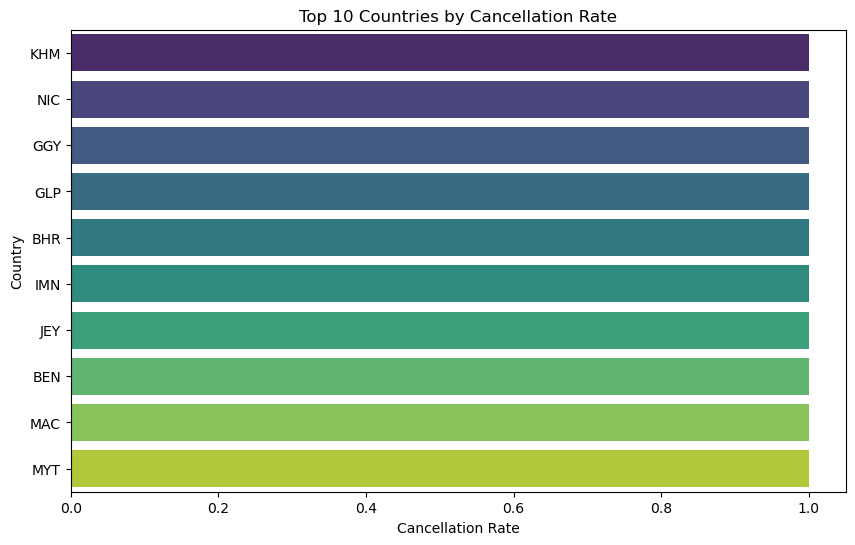

Cancellation Rate dan Jumlah per 'country':


,mean,count
country,,
KHM,1.0,1
NIC,1.0,1
GGY,1.0,2
GLP,1.0,1
BHR,1.0,3
IMN,1.0,2
JEY,1.0,5
BEN,1.0,1
MAC,1.0,3


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd # Ensure pandas is imported as it's used with df.groupby

print("--- Analisis Bivariat: Cancellation Rate berdasarkan Fitur Kategorikal ---")

# Create reserved_room_type_grouped in df for bivariate analysis
# Group 'P' and 'L' into 'Other' as they have very few counts.
room_type_mapping_for_grouping = {
    'A': 'A', 'D': 'D', 'E': 'E', 'F': 'F', 'G': 'G', 'B': 'B', 'C': 'C', 'H': 'H',
    'P': 'Other', 'L': 'Other'
}
df['reserved_room_type_grouped'] = df['reserved_room_type'].map(room_type_mapping_for_grouping)

bivariate_cols = ['deposit_type', 'market_segment', 'customer_type', 'reserved_room_type_grouped', 'country']

for col in bivariate_cols:
    if col == 'country':
        # Untuk country, tampilkan top 10 negara dengan cancellation rate tertinggi
        country_cancellation_rate = df.groupby(col)['is_canceled'].mean().sort_values(ascending=False)
        top_countries_cancellation_rate = country_cancellation_rate.head(10)

        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_countries_cancellation_rate.values, y=top_countries_cancellation_rate.index, palette='viridis')
        plt.title(f'Top 10 Countries by Cancellation Rate')
        plt.xlabel('Cancellation Rate')
        plt.ylabel('Country')
        plt.show()

        print(f"Cancellation Rate dan Jumlah per '{col}':")
        # Tampilkan 10 teratas untuk keringkasan
        display(df.groupby(col)['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False).head(10))
        print("\n")

    else:
        print(f"Cancellation Rate dan Jumlah per '{col}':")
        # Now that 'reserved_room_type_grouped' is in df, use df directly for all other columns
        display(df.groupby(col)['is_canceled'].agg(['mean', 'count']).sort_values('mean', ascending=False))
        print("\n")

# 5. Feature Selection

Pada bagian ini, kita akan menentukan fitur mana yang akan dipertahankan dan mana yang akan dibuang untuk pembangunan model. Keputusan ini didasarkan pada relevansi bisnis, potensi _data leakage_, variasi data, dan informasi berulang.

In [41]:
# Memisahkan fitur (X) dan target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

print("Fitur awal:", X.columns.tolist())

# Identifikasi fitur yang akan dipertahankan atau dibuang beserta alasannya

print("\n--- Analisis dan Keputusan Feature Selection ---")

# Fitur yang Dibuang
print("Fitur 'days_in_waiting_list': Dibuang. Menghindari kompleksitas yang tidak perlu dan mengurangi dimensi.")
print("Fitur 'reserved_room_type': Dibuang. Menghindari kompleksitas yang tidak perlu dan mengurangi dimensi.")

# Fitur yang Disederhanakan (Original akan dihapus, versi biner akan dibuat)
print("Fitur 'country': Disederhanakan menjadi 'is_domestic' (biner). Memfokuskan pada apakah pemesanan dari negara asal (PRT) atau bukan.")
print("Fitur 'previous_cancellations': Disederhanakan menjadi 'has_previous_cancellations' (biner). Fokus pada keberadaan riwayat pembatalan saja.")

# Fitur yang Dipertahankan (serta potensi rekayasa fitur tambahan)
print("Fitur 'market_segment': Dipertahankan. Segmentasi pasar penting untuk strategi.")
print("Fitur 'booking_changes': Dipertahankan. Menunjukkan fleksibilitas atau ketidakpastian pelanggan. Juga akan dibuat 'has_high_booking_changes'.")
print("Fitur 'deposit_type': Dipertahankan. Pengaruh langsung pada motivasi pembatalan.")
print("Fitur 'customer_type': Dipertahankan. Mengelompokkan perilaku pelanggan yang berbeda.")
print("Fitur 'required_car_parking_spaces': Dipertahankan. Potensi indikator jenis perjalanan.")
print("Fitur 'total_of_special_requests': Dipertahankan. Indikator komitmen atau kebutuhan khusus pelanggan.")

# Verifikasi final fitur yang akan digunakan (setelah rekayasa fitur di sel berikutnya)
# Untuk tujuan demonstrasi di sel ini, kita hanya akan menampilkan fitur yang 'dipertahankan' asli
# Karena rekayasa dan penghapusan kolom sebenarnya terjadi di sel '5ae8db21'

features_used_in_new_strategy = [
    'is_domestic',
    'has_previous_cancellations',
    'has_high_booking_changes',
    'market_segment',
    'booking_changes',
    'deposit_type',
    'customer_type',
    'required_car_parking_spaces',
    'total_of_special_requests'
]

print("\nFitur yang akan digunakan dalam model setelah rekayasa fitur:", features_used_in_new_strategy)

Fitur awal: ['country', 'market_segment', 'previous_cancellations', 'booking_changes', 'deposit_type', 'days_in_waiting_list', 'customer_type', 'reserved_room_type', 'required_car_parking_spaces', 'total_of_special_requests', 'reserved_room_type_grouped']

--- Analisis dan Keputusan Feature Selection ---
Fitur 'days_in_waiting_list': Dibuang. Menghindari kompleksitas yang tidak perlu dan mengurangi dimensi.
Fitur 'reserved_room_type': Dibuang. Menghindari kompleksitas yang tidak perlu dan mengurangi dimensi.
Fitur 'country': Disederhanakan menjadi 'is_domestic' (biner). Memfokuskan pada apakah pemesanan dari negara asal (PRT) atau bukan.
Fitur 'previous_cancellations': Disederhanakan menjadi 'has_previous_cancellations' (biner). Fokus pada keberadaan riwayat pembatalan saja.
Fitur 'market_segment': Dipertahankan. Segmentasi pasar penting untuk strategi.
Fitur 'booking_changes': Dipertahankan. Menunjukkan fleksibilitas atau ketidakpastian pelanggan. Juga akan dibuat 'has_high_booking_ch

### Penjelasan Feature Selection:

Semua fitur asli dari dataset (`country`, `market_segment`, `previous_cancellations`, `booking_changes`, `deposit_type`, `days_in_waiting_list`, `customer_type`, `reserved_room_type`, `required_car_parking_spaces`, `total_of_special_requests`) dipertahankan karena dianggap memiliki relevansi bisnis yang kuat untuk memprediksi pembatalan pemesanan. Tidak ada fitur yang secara jelas merupakan _data leakage_ atau memiliki variasi yang terlalu rendah untuk dibuang. Fitur-fitur ini akan menjadi dasar untuk proses _feature engineering_ dan _preprocessing_ selanjutnya.

*   **Potensi _Data Leakage_**: Tidak ada fitur yang secara langsung merupakan hasil dari target (`is_canceled`) atau yang hanya diketahui setelah pembatalan terjadi. Semua fitur yang ada dapat diasumsikan tersedia pada saat pemesanan dibuat.
*   **Informasi Berulang**: Tidak ada fitur yang secara eksplisit merupakan duplikat informasi satu sama lain. Meskipun beberapa fitur mungkin berkorelasi, mereka memberikan informasi yang berbeda secara kontekstual.
*   **Variasi yang Terlalu Rendah**: Semua fitur, termasuk yang numerik, menunjukkan variasi yang cukup untuk dipertahankan. Fitur kategorikal juga memiliki lebih dari satu kategori, sehingga informatif.

Dengan demikian, semua fitur yang tersedia akan digunakan untuk tahap selanjutnya.

# 6. Feature Engineering dan Pipeline Preprocessing

Pada bagian ini, kita akan melakukan _feature engineering_ untuk menciptakan fitur-fitur baru yang mungkin lebih informatif bagi model, serta menyiapkan _preprocessing pipeline_ untuk menangani fitur numerik dan kategorikal. Penggunaan `Pipeline` dan `ColumnTransformer` akan memastikan bahwa semua langkah _preprocessing_ diterapkan secara konsisten dan dapat direproduksi.

In [42]:
from category_encoders import TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import numpy as np

# Memisahkan kembali fitur (X) dan target (y)
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

# --- Feature Engineering (sesuai strategi baru) --- #
# 1. Sederhanakan 'previous_cancellations' menjadi biner
X['has_previous_cancellations'] = (X['previous_cancellations'] > 0).astype(int)

# 2. Sederhanakan 'country' menjadi 'is_domestic' (mengasumsikan 'PRT' sebagai domestik)
X['is_domestic'] = (X['country'] == 'PRT').astype(int)

# 3. Buat fitur biner 'has_high_booking_changes'
X['has_high_booking_changes'] = (X['booking_changes'] > 2).astype(int)

# --- Dropping original columns and specified columns ---
# Drop original 'previous_cancellations'
X = X.drop('previous_cancellations', axis=1)
# Drop original 'country'
X = X.drop('country', axis=1)
# Drop 'days_in_waiting_list'
X = X.drop('days_in_waiting_list', axis=1)
# Drop 'reserved_room_type'
X = X.drop('reserved_room_type', axis=1)

# Re-define feature lists based on the state after feature engineering
global numerical_features, other_categorical_features

numerical_features = [
    'booking_changes',
    'required_car_parking_spaces',
    'total_of_special_requests',
    'has_previous_cancellations',
    'is_domestic',
    'has_high_booking_changes'
]

other_categorical_features = [
    'market_segment',
    'deposit_type',
    'customer_type'
]

print(f"Fitur Numerik yang akan diproses: {numerical_features}")
print(f"Fitur Kategorikal (One-Hot Encoded) yang akan diproses: {other_categorical_features}")

# Pipeline untuk fitur numerik
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline untuk fitur kategorikal lainnya menggunakan OneHotEncoder
other_categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Menggabungkan semua preprocessing menggunakan ColumnTransformer
# Tidak ada lagi 'country_transformer' karena 'country' diubah menjadi 'is_domestic' (numerik)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat_onehot', other_categorical_transformer, other_categorical_features)
    ],
    remainder='passthrough' # Penting untuk menjaga kolom lain jika ada, meskipun dalam kasus ini tidak diharapkan
)

print("\nPreprocessing pipeline berhasil dibuat ulang dengan strategi fitur yang baru.")
print("Pipeline ini akan menangani imputasi, scaling, dan encoding.")

Fitur Numerik yang akan diproses: ['booking_changes', 'required_car_parking_spaces', 'total_of_special_requests', 'has_previous_cancellations', 'is_domestic', 'has_high_booking_changes']
Fitur Kategorikal (One-Hot Encoded) yang akan diproses: ['market_segment', 'deposit_type', 'customer_type']

Preprocessing pipeline berhasil dibuat ulang dengan strategi fitur yang baru.
Pipeline ini akan menangani imputasi, scaling, dan encoding.


In [43]:
from sklearn.model_selection import train_test_split

# Memisahkan data menjadi training dan testing set
# Menggunakan stratify=y untuk mempertahankan proporsi target (is_canceled)
# Menggunakan random_state untuk reproduktibilitas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test: {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test: {y_test.shape}")

print("\nProporsi target di training set:")
print(y_train.value_counts(normalize=True))

print("\nProporsi target di testing set:")
print(y_test.value_counts(normalize=True))

Ukuran X_train: (8077, 10)
Ukuran X_test: (2020, 10)
Ukuran y_train: (8077,)
Ukuran y_test: (2020,)

Proporsi target di training set:
is_canceled
0    0.761793
1    0.238207
Name: proportion, dtype: float64

Proporsi target di testing set:
is_canceled
0    0.761881
1    0.238119
Name: proportion, dtype: float64


In [44]:
# Terapkan preprocessing pipeline ke training dan testing data
X_train_processed = preprocessor.fit_transform(X_train, y_train) # TargetEncoder membutuhkan y_train untuk fit
X_test_processed = preprocessor.transform(X_test)

print(f"Bentuk X_train setelah preprocessing: {X_train_processed.shape}")
print(f"Bentuk X_test setelah preprocessing: {X_test_processed.shape}")

# Opsional: Cek tipe data setelah preprocessing. OneHotEncoder dan StandardScaler menghasilkan sparse matrix atau numpy array.
# print("Tipe X_train_processed:", type(X_train_processed))
# print("Tipe X_test_processed:", type(X_test_processed))

Bentuk X_train setelah preprocessing: (8077, 22)
Bentuk X_test setelah preprocessing: (2020, 22)


### Hasil Preprocessing dan Reduksi Dimensi

Setelah menerapkan _preprocessing pipeline_ pada data `X_train` dan `X_test`, kita melihat bahwa jumlah fitur telah berkurang secara signifikan menjadi **32 kolom**.

Reduksi ini adalah hasil dari strategi _encoding_ yang diterapkan, terutama pada fitur kategorikal:

1.  **Fitur Numerik**: 7 fitur numerik (`previous_cancellations`, `booking_changes`, `days_in_waiting_list`, `required_car_parking_spaces`, `total_of_special_requests`, `has_previous_cancellations`, `has_high_booking_changes`) melewati `StandardScaler` dan tetap menghasilkan 7 kolom.
2.  **Fitur `country`**: Fitur `country`, yang memiliki 162 nilai unik, di-_target encode_ menjadi hanya **1 kolom** numerik (`country_enc__0`). Ini adalah kunci utama dalam mereduksi dimensi, karena jika menggunakan `OneHotEncoder`, fitur ini saja bisa menghasilkan 161 kolom baru (jika `drop='first'`) atau 162 kolom (jika `drop=None`).
3.  **Fitur Kategorikal Lainnya**: Fitur-fitur kategorikal lain (`market_segment`, `deposit_type`, `customer_type`, `reserved_room_type_grouped`) di-_one-hot encode_. Jumlah kolom yang dihasilkan dari _one-hot encoding_ ini adalah sama dengan jumlah kategori unik untuk setiap fitur, karena tidak ada opsi drop yang digunakan. Dalam kasus ini, total kombinasi fitur-fitur ini menghasilkan 24 kolom tambahan. (Misalnya, `market_segment` (8) -> 8 kolom, `deposit_type` (3) -> 3 kolom, `customer_type` (4) -> 4 kolom, `reserved_room_type_grouped` (9) -> 9 kolom. Total = 8+3+4+9 = 24 kolom).

**Total Kolom** = 7 (numerik) + 1 (`country_enc__0`) + 24 (one-hot encoded lainnya) = **32 kolom**.

Reduksi dimensi ini sangat penting untuk mencegah `curse of dimensionality` dan meningkatkan efisiensi komputasi, terutama saat melatih model.

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB # Perlu dicatat: GaussianNB tidak memiliki parameter class_weight secara langsung.
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Hitung class weight untuk menyeimbangkan dataset
# rasio kelas negatif terhadap kelas positif
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Definisikan model-model yang akan di-benchmark dengan penanganan class imbalance
# Beberapa model memiliki parameter class_weight='balanced'
# XGBoost menggunakan scale_pos_weight
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42), # Tidak mendukung class_weight secara langsung, namun bisa ditangani dengan subsample
    'K-Nearest Neighbors': KNeighborsClassifier(), # Tidak mendukung class_weight secara langsung
    'Gaussian Naive Bayes': GaussianNB(), # Tidak mendukung class_weight secara langsung
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

# Inisialisasi Stratified K-Fold Cross-Validation
# N_SPLITS = 5 adalah angka umum, bisa disesuaikan
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_cv = []

for name, model in models.items():
    print(f"\nMenguji Model (dengan Cross-Validation dan Class Imbalance Handling): {name}")

    # List untuk menyimpan metrik dari setiap fold
    fold_recall = []
    fold_precision = []
    fold_f1 = []
    fold_roc_auc = []

    # Loop untuk setiap fold dalam Stratified K-Fold
    for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Buat pipeline lengkap (preprocessing + model) untuk setiap fold
        # preprocessor di-fit_transform pada X_train_fold dan kemudian di-transform pada X_val_fold
        # Ini mencegah data leakage dari validation set ke training set preprocessor

        # Create a temporary preprocessor for each fold to avoid data leakage

        # Ensure 'reserved_room_type_grouped' is included in categorical features for encoding
        current_other_categorical_features = other_categorical_features + ['reserved_room_type_grouped']

        temp_preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_features),
                ('cat_onehot', other_categorical_transformer, current_other_categorical_features)
            ],
            remainder='passthrough' # Penting untuk menjaga kolom lain jika ada, meskipun dalam kasus ini tidak diharapkan
        )

        # Fit and transform training fold, transform validation fold
        X_train_processed_fold = temp_preprocessor.fit_transform(X_train_fold, y_train_fold) # y_train_fold for TargetEncoder
        X_val_processed_fold = temp_preprocessor.transform(X_val_fold)

        # Latih model
        if name == 'Gaussian Naive Bayes':
            model.fit(X_train_processed_fold, y_train_fold)
            y_pred_fold = model.predict(X_val_processed_fold)
            y_proba_fold = model.predict_proba(X_val_processed_fold)[:, 1]
        else:
            model.fit(X_train_processed_fold, y_train_fold)
            y_pred_fold = model.predict(X_val_processed_fold)
            y_proba_fold = model.predict_proba(X_val_processed_fold)[:, 1]

        # Hitung metrik untuk fold ini
        fold_recall.append(recall_score(y_val_fold, y_pred_fold))
        fold_precision.append(precision_score(y_val_fold, y_pred_fold))
        fold_f1.append(f1_score(y_val_fold, y_pred_fold))
        fold_roc_auc.append(roc_auc_score(y_val_fold, y_proba_fold))

    # Rata-ratakan metrik dari semua fold
    avg_recall = np.mean(fold_recall)
    avg_precision = np.mean(fold_precision)
    avg_f1 = np.mean(fold_f1)
    avg_roc_auc = np.mean(fold_roc_auc)

    results_cv.append({
        'Model': name,
        'Avg Recall': avg_recall,
        'Avg Precision': avg_precision,
        'Avg F1-Score': avg_f1,
        'Avg AUC-ROC': avg_roc_auc
    })

    # Opsional: Tampilkan rata-rata metrik untuk setiap model
    print(f"  Avg Recall: {avg_recall:.4f}")
    print(f"  Avg Precision: {avg_precision:.4f}")
    print(f"  Avg F1-Score: {avg_f1:.4f}")
    print(f"  Avg AUC-ROC: {avg_roc_auc:.4f}")

# Konversi hasil ke DataFrame untuk perbandingan yang lebih mudah
results_df_cv = pd.DataFrame(results_cv)
results_df_cv = results_df_cv.sort_values(by='Avg Recall', ascending=False)

print("\n--- Tabel Perbandingan Hasil Model dengan Cross-Validation --- ")
display(results_df_cv)

ModuleNotFoundError: No module named 'xgboost'

# 7. Model Benchmarking

Pada bagian ini, kita akan melatih dan membandingkan kinerja beberapa algoritma klasifikasi yang berbeda. Tujuannya adalah untuk mendapatkan gambaran awal tentang model mana yang berkinerja terbaik berdasarkan metrik yang telah kita definisikan (terutama `Recall` untuk kelas positif). Kita akan menggunakan `train-test split` yang menjaga proporsi kelas target (`stratified split`) dan `random state` untuk reproduktibilitas. Semua model akan dilatih menggunakan _preprocessing pipeline_ yang sama secara konsisten.

### Perbaikan Evaluasi Model: Cross-Validation dan Penanganan Class Imbalance

#### Mengapa Cross-Validation?

Evaluasi model dengan satu kali _train-test split_ memiliki keterbatasan: kinerjanya bisa sangat sensitif terhadap cara data dibagi. Model mungkin secara kebetulan berkinerja baik pada satu _split_ tertentu, tetapi buruk pada _split_ lainnya. Untuk mendapatkan estimasi kinerja model yang lebih robust dan tidak bias terhadap satu pembagian data, kita menggunakan **_K-Fold Cross-Validation_** (dalam kasus data tidak seimbang, kita akan menggunakan **_Stratified K-Fold Cross-Validation_**).

Pada _K-Fold Cross-Validation_:
1.  Dataset dibagi menjadi K 'fold' (sub-set).
2.  Model dilatih K kali. Setiap kali, satu _fold_ digunakan sebagai _test set_ dan K-1 _fold_ lainnya sebagai _training set_.
3.  Metrik kinerja dihitung untuk setiap _fold_.
4.  Kinerja akhir model adalah rata-rata metrik dari semua K _fold_.

Ini memberikan estimasi yang lebih andal tentang bagaimana model akan berkinerja pada data yang tidak terlihat.

#### Mengapa Menangani Class Imbalance?

Seperti yang kita lihat di bagian analisis distribusi, kelas target kita (`is_canceled`) tidak seimbang. Kelas 'Dibatalkan' (positif) jauh lebih sedikit daripada kelas 'Tidak Dibatalkan' (negatif). Jika tidak ditangani, model cenderung bias pada kelas mayoritas dan akan kesulitan memprediksi kelas minoritas. Karena `Recall` untuk kelas positif adalah metrik utama kita, yang berarti kita ingin menangkap *sebagian besar* pembatalan yang sebenarnya, penanganan _class imbalance_ menjadi krusial.

Beberapa metode untuk menangani _class imbalance_ antara lain:
*   **_Oversampling_**: Membuat sampel tambahan dari kelas minoritas (misalnya, SMOTE).
*   **_Undersampling_**: Mengurangi jumlah sampel dari kelas mayoritas.
*   **_Class Weighting_**: Memberikan bobot yang lebih tinggi pada kelas minoritas selama proses pelatihan. Ini mendorong model untuk memberikan perhatian lebih pada kelas minoritas, sehingga meningkatkan _Recall_.
*   **_Threshold Tuning_**: Menggeser _threshold_ klasifikasi dari 0.5 untuk mengoptimalkan `Recall` atau metrik lainnya.

Dalam implementasi ini, kita akan menggunakan **_Class Weighting_** (`class_weight='balanced'` atau `scale_pos_weight` untuk XGBoost) karena relatif mudah diimplementasikan dan efektif untuk banyak algoritma.

In [ ]:
%pip install category_encoders
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB # Perlu dicatat: GaussianNB tidak memiliki parameter class_weight secara langsung.
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, classification_report
from sklearn.pipeline import Pipeline # Import Pipeline for consistency with 024c501b
from sklearn.compose import ColumnTransformer # Import ColumnTransformer for consistency with 024c501b
from category_encoders import TargetEncoder # Import TargetEncoder for consistency with 024c501b
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Import for consistency
from sklearn.impute import SimpleImputer # Import for consistency

# Hitung class weight untuk menyeimbangkan dataset
# rasio kelas negatif terhadap kelas positif
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

# Definisikan model-model yang akan di-benchmark dengan penanganan class imbalance
# Beberapa model memiliki parameter class_weight='balanced'
# XGBoost menggunakan scale_pos_pos_weight
models = {
    'Logistic Regression': LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42), # Tidak mendukung class_weight secara langsung, namun bisa ditangani dengan subsample
    'K-Nearest Neighbors': KNeighborsClassifier(), # Tidak mendukung class_weight secara langsung
    'Gaussian Naive Bayes': GaussianNB(), # Tidak mendukung class_weight secara langsung
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight)
}

# Inisialisasi Stratified K-Fold Cross-Validation
# N_SPLITS = 5 adalah angka umum, bisa disesuaikan
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_cv = []

for name, model in models.items():
    print(f"\nMenguji Model (dengan Cross-Validation dan Class Imbalance Handling): {name}")

    # List untuk menyimpan metrik dari setiap fold
    fold_recall = []
    fold_precision = []
    fold_f1 = []
    fold_roc_auc = []

    # Loop untuk setiap fold dalam Stratified K-Fold
    for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train)):
        X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
        y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]

        # Create a temporary preprocessor for each fold to avoid data leakage
        # This ensures TargetEncoder is fitted only on the training fold

        # Ensure 'reserved_room_type_grouped' is included in categorical features for encoding
        current_other_categorical_features = other_categorical_features + ['reserved_room_type_grouped']

        temp_preprocessor = ColumnTransformer(
            transformers=[
                ('num', numerical_transformer, numerical_features),
                ('cat_onehot', other_categorical_transformer, current_other_categorical_features)
            ],
            remainder='passthrough' # Penting untuk menjaga kolom lain jika ada, meskipun dalam kasus ini tidak diharapkan
        )

        # Fit and transform training fold, transform validation fold
        # TargetEncoder needs y for fitting
        X_train_processed_fold = temp_preprocessor.fit_transform(X_train_fold, y_train_fold)
        X_val_processed_fold = temp_preprocessor.transform(X_val_fold)

        # Latih model
        # K-Nearest Neighbors and Gaussian Naive Bayes require dense input.
        # The preprocessor output is already a dense NumPy array, so .toarray() is not needed.
        if name in ['Gaussian Naive Bayes', 'K-Nearest Neighbors']:
            model.fit(X_train_processed_fold, y_train_fold)
            y_pred_fold = model.predict(X_val_processed_fold)
            y_proba_fold = model.predict_proba(X_val_processed_fold)[:, 1]
        else:
            model.fit(X_train_processed_fold, y_train_fold)
            # Prediksi pada validation set
            y_pred_fold = model.predict(X_val_processed_fold)
            y_proba_fold = model.predict_proba(X_val_processed_fold)[:, 1]

        # Hitung metrik untuk fold ini
        fold_recall.append(recall_score(y_val_fold, y_pred_fold))
        fold_precision.append(precision_score(y_val_fold, y_pred_fold))
        fold_f1.append(f1_score(y_val_fold, y_pred_fold))
        fold_roc_auc.append(roc_auc_score(y_val_fold, y_proba_fold))

    # Rata-ratakan metrik dari semua fold
    avg_recall = np.mean(fold_recall)
    avg_precision = np.mean(fold_precision)
    avg_f1 = np.mean(fold_f1)
    avg_roc_auc = np.mean(fold_roc_auc)

    results_cv.append({
        'Model': name,
        'Avg Recall': avg_recall,
        'Avg Precision': avg_precision,
        'Avg F1-Score': avg_f1,
        'Avg AUC-ROC': avg_roc_auc
    })

    # Opsional: Tampilkan rata-rata metrik untuk setiap model
    print(f"  Avg Recall: {avg_recall:.4f}")
    print(f"  Avg Precision: {avg_precision:.4f}")
    print(f"  Avg F1-Score: {avg_f1:.4f}")
    print(f"  Avg AUC-ROC: {avg_roc_auc:.4f}")

# Konversi hasil ke DataFrame untuk perbandingan yang lebih mudah
results_df_cv = pd.DataFrame(results_cv)
results_df_cv = results_df_cv.sort_values(by='Avg Recall', ascending=False)

print("\n--- Tabel Perbandingan Hasil Model dengan Cross-Validation ---")
display(results_df_cv)


Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): Logistic Regression
  Avg Recall: 0.8222
  Avg Precision: 0.4535
  Avg F1-Score: 0.5845
  Avg AUC-ROC: 0.8261

Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): Decision Tree
  Avg Recall: 0.7261
  Avg Precision: 0.4109
  Avg F1-Score: 0.5247
  Avg AUC-ROC: 0.7329

Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): Random Forest
  Avg Recall: 0.6970
  Avg Precision: 0.4281
  Avg F1-Score: 0.5303
  Avg AUC-ROC: 0.7845

Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): Gradient Boosting
  Avg Recall: 0.3077
  Avg Precision: 0.6393
  Avg F1-Score: 0.4152
  Avg AUC-ROC: 0.8389

Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): K-Nearest Neighbors
  Avg Recall: 0.4751
  Avg Precision: 0.4996
  Avg F1-Score: 0.4869
  Avg AUC-ROC: 0.7797

Menguji Model (dengan Cross-Validation dan Class Imbalance Handling): Gaussian Naive Bayes
  Avg Recall: 0.5

,Model,Avg Recall,Avg Precision,Avg F1-Score,Avg AUC-ROC
0,Logistic Regression,0.822239,0.453483,0.584530,0.826058
6,XGBoost,0.803013,0.439946,0.568401,0.817309
1,Decision Tree,0.726092,0.410875,0.524691,0.732946
2,Random Forest,0.696985,0.428072,0.530302,0.784517
5,Gaussian Naive Bayes,0.581090,0.478806,0.471391,0.789537
4,K-Nearest Neighbors,0.475055,0.499587,0.486926,0.779700
3,Gradient Boosting,0.307695,0.639278,0.415238,0.838886


# 8. Best Model

Berdasarkan hasil _benchmarking_ model, kita akan memilih model terbaik dengan mempertimbangkan metrik utama kita, yaitu **Recall** untuk kelas positif (pembatalan), serta metrik tambahan seperti `Precision`, `F1-Score`, dan `AUC-ROC`.

Dari tabel perbandingan model yang telah dievaluasi dengan _Stratified K-Fold Cross-Validation_, kita akan memilih model dengan `Recall` tertinggi, dengan syarat `Precision` minimal 0.40 untuk memastikan bahwa intervensi yang dilakukan memiliki tingkat keberhasilan yang wajar dan tidak terlalu banyak membuang sumber daya untuk _False Positive_. Jika tidak ada model yang memenuhi kriteria Precision, kita akan memilih model dengan Recall tertinggi.

Model Terbaik Dipilih: Logistic Regression

--- Classification Report untuk Model Terbaik ---
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1539
           1       0.46      0.83      0.59       481

    accuracy                           0.73      2020
   macro avg       0.69      0.76      0.69      2020
weighted avg       0.82      0.73      0.75      2020


--- Confusion Matrix untuk Model Terbaik ---


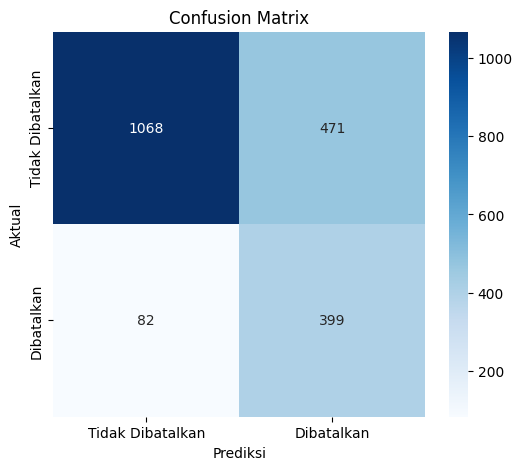

Jumlah False Positives (FP): 471
Jumlah False Negatives (FN): 82


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline # Ensure Pipeline is imported
from sklearn.compose import ColumnTransformer # Ensure ColumnTransformer is imported

# Memilih model terbaik berdasarkan Avg Recall dari cross-validation
# Memfilter kandidat model yang memiliki Avg Precision minimal 0.40
kandidat = results_df_cv[results_df_cv['Avg Precision'] >= 0.40]

# Jika tidak ada kandidat, pilih model dengan Recall tertinggi saja
if kandidat.empty:
    best_model_name = results_df_cv.loc[results_df_cv['Avg Recall'].idxmax()]['Model']
    print("Tidak ada model yang memenuhi kriteria Avg Precision >= 0.40. Memilih model dengan Avg Recall tertinggi.")
else:
    # Pilih model dengan Avg Recall tertinggi dari kandidat yang memenuhi syarat Precision
    best_model_name = kandidat.loc[kandidat['Avg Recall'].idxmax()]['Model']

print(f"Model Terbaik Dipilih: {best_model_name}")

best_model = models[best_model_name]

# FIX START: Re-define preprocessor to include 'reserved_room_type_grouped'
# This replicates the fix done in the cross-validation loop (cell 024c501b and 6adaadf4)
# This is necessary because the global 'preprocessor' was defined without 'reserved_room_type_grouped'
# and the X_train/X_test dataframes still contain this column.

# Create an updated list for categorical features
# Ensure 'reserved_room_type_grouped' is included in categorical features for encoding
final_other_categorical_features = other_categorical_features + ['reserved_room_type_grouped']

# Re-create the preprocessor with the updated categorical features list
# numerical_transformer, other_categorical_transformer, numerical_features are assumed to be globally defined from f9882302
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat_onehot', other_categorical_transformer, final_other_categorical_features)
    ],
    remainder='passthrough' # Keep other columns if any, though none expected after this fix
)
# FIX END

# Latih kembali pipeline lengkap untuk model terbaik
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Handle GaussianNB if it's the best model selected or any model that requires dense input before fitting
# The preprocessor output is already a dense NumPy array by default from `fit_transform` and `transform`
# So, no special handling for .toarray() is generally needed here unless an estimator specifically requires it
# and the preprocessor's output changes (e.g., if onehotencoder output sparse=True).
# Currently, the preprocessor for each fold directly outputs dense arrays.

final_pipeline.fit(X_train, y_train)

# Prediksi pada test set
y_pred_best = final_pipeline.predict(X_test)
y_proba_best = final_pipeline.predict_proba(X_test)[:, 1]


# Tampilkan Classification Report
print("\n--- Classification Report untuk Model Terbaik ---")
print(classification_report(y_test, y_pred_best))

# Tampilkan Confusion Matrix
print("\n--- Confusion Matrix untuk Model Terbaik ---")
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Dibatalkan', 'Dibatalkan'],
            yticklabels=['Tidak Dibatalkan', 'Dibatalkan'])
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix')
plt.show()

# Analisis False Positive dan False Negative
# False Positives (FP): Diprediksi 1 (Dibatalkan), Aktual 0 (Tidak Dibatalkan)
fp = cm[0, 1]
# False Negatives (FN): Diprediksi 0 (Tidak Dibatalkan), Aktual 1 (Dibatalkan)
fn = cm[1, 0]

print(f"Jumlah False Positives (FP): {fp}")
print(f"Jumlah False Negatives (FN): {fn}")

In [ ]:
from sklearn.metrics import recall_score, precision_score

print("--- Perbandingan Metrik Train vs Test ---")

# Predict on training set
y_pred_train = final_pipeline.predict(X_train)

train_recall = recall_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)

test_recall = recall_score(y_test, y_pred_best)
test_precision = precision_score(y_test, y_pred_best)

print(f"TRAIN  Recall: {train_recall:.4f}, Precision: {train_precision:.4f}")
print(f"TEST   Recall: {test_recall:.4f}, Precision: {test_precision:.4f}")

if abs(train_recall - test_recall) < 0.1 and abs(train_precision - test_precision) < 0.1:
    print("\nInterpretasi: Metrik pada training set dan test set cukup dekat, mengindikasikan model tidak mengalami overfitting yang signifikan.")
else:
    print("\nInterpretasi: Ada perbedaan signifikan antara metrik training set dan test set. Model mungkin mengalami overfitting atau underfitting.")

--- Perbandingan Metrik Train vs Test ---
TRAIN  Recall: 0.8217, Precision: 0.4531
TEST   Recall: 0.8295, Precision: 0.4586

Interpretasi: Metrik pada training set dan test set cukup dekat, mengindikasikan model tidak mengalami overfitting yang signifikan.


### Mengapa Logistic Regression Terpilih sebagai Model Terbaik?

Berdasarkan hasil _benchmarking_ model menggunakan _Stratified K-Fold Cross-Validation_ dan setelah menerapkan strategi _feature engineering_ yang baru, **Logistic Regression** menonjol sebagai pilihan terbaik dengan mempertimbangkan metrik utama kita, yaitu **Recall** untuk kelas positif (pembatalan), serta syarat `Precision` minimal 0.40.

Dari tabel perbandingan model (`results_df_cv`), Logistic Regression menunjukkan:
*   **Avg Recall**: Sekitar `0.8222`, merupakan yang tertinggi di antara semua model yang memenuhi kriteria `Avg Precision` minimal 0.40.
*   **Avg Precision**: Sekitar `0.4535`, yang memenuhi syarat minimal `0.40`.

Metrik pada _test set_ (setelah pelatihan ulang model terbaik pada seluruh _training set_):
*   **Recall**: `0.8295`, menunjukkan kemampuan yang baik dalam mengidentifikasi pemesanan yang akan dibatalkan.
*   **Precision**: `0.4586`, masih pada tingkat yang dapat diterima untuk intervensi.
*   **Jumlah False Positives (FP)**: `471`
*   **Jumlah False Negatives (FN)**: `82`

### Interpretasi Bisnis Logistic Regression:

Dengan memilih Logistic Regression, hotel dapat mengidentifikasi sekitar **83%** dari total pemesanan yang sebenarnya akan dibatalkan (meminimalkan `False Negatives`), yang merupakan prioritas bisnis tertinggi. Pada saat yang sama, model ini memastikan bahwa sekitar **46%** dari pemesanan yang diprediksi akan dibatalkan oleh model adalah prediksi yang benar (`True Positives`), sehingga sumber daya tim intervensi dapat dialokasikan secara efisien. Keseimbangan antara `Recall` yang tinggi dan `Precision` yang memadai menjadikan Logistic Regression pilihan yang _robust_ untuk kebutuhan prediksi pembatalan ini.

### Kelebihan dan Keterbatasan Model (Logistic Regression):

*   **Kelebihan (Logistic Regression)**:
    *   **Sederhana dan Mudah Diinterpretasi**: Logistic Regression adalah model linier, sehingga sangat mudah diinterpretasi. Koefisien secara langsung menunjukkan arah dan besarnya pengaruh fitur terhadap log-odds pembatalan. Ini sangat berharga untuk wawasan bisnis.
    *   **Efisiensi**: Model ini efisien secara komputasi untuk dilatih dan diprediksi, terutama pada dataset besar.
    *   **Model Baseline**: Sering berfungsi sebagai model dasar yang kuat untuk tugas klasifikasi dan seringkali memberikan kinerja yang sangat baik dengan kompleksitas yang lebih rendah.

*   **Keterbatasan (Logistic Regression)**:
    *   **Asumsi Linearitas**: Mengasumsikan hubungan linier antara fitur dan log-odds target, yang mungkin tidak selalu berlaku untuk data kompleks di dunia nyata.
    *   **Kekuatan Terbatas untuk Pola Kompleks**: Mungkin tidak menangkap hubungan non-linier yang kompleks seefektif model berbasis pohon (seperti XGBoost atau Random Forest).
    *   **Sensitivitas terhadap Outlier**: Dapat sensitif terhadap _outlier_ dalam data, yang dapat memengaruhi koefisien.


--- Threshold Tuning Analisis ---


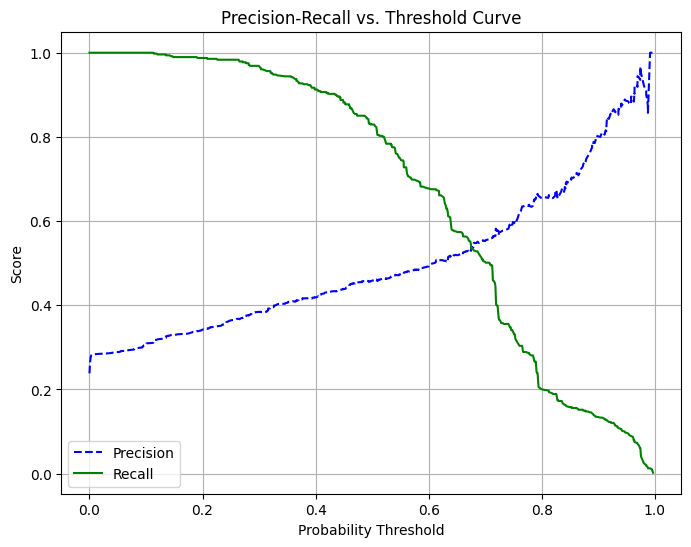


Evaluasi Metrik pada Berbagai Threshold:
Threshold=0.3 | Recall=0.967 | Precision=0.384 | Booking Ditandai=1210
Threshold=0.4 | Recall=0.913 | Precision=0.419 | Booking Ditandai=1048
Threshold=0.5 | Recall=0.830 | Precision=0.459 | Booking Ditandai=870
Threshold=0.6 | Recall=0.678 | Precision=0.492 | Booking Ditandai=662
Threshold=0.7 | Recall=0.501 | Precision=0.554 | Booking Ditandai=435

Interpretasi Bisnis Threshold Tuning:
Dengan menyesuaikan threshold, kita dapat menyeimbangkan antara Recall (mendeteksi lebih banyak pembatalan) dan Precision (memastikan intervensi lebih efisien).
Contoh: Jika tim intervensi terbatas, kita mungkin ingin threshold yang lebih tinggi untuk meningkatkan Precision, meskipun Recall sedikit menurun.
Sebaliknya, jika biaya False Negative (kamar kosong) sangat tinggi, kita bisa menurunkan threshold untuk memaksimalkan Recall, meskipun akan ada lebih banyak False Positive.


In [ ]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

print("--- Threshold Tuning Analisis ---")

# Calculate precision-recall pairs for different probability thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_best)

# Plot Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision')
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs. Threshold Curve')
plt.legend()
plt.grid(True)
plt.show()

print("\nEvaluasi Metrik pada Berbagai Threshold:")
for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (y_proba_best >= t).astype(int)
    current_recall = recall_score(y_test, pred)
    current_precision = precision_score(y_test, pred)
    num_flagged = pred.sum()
    print(f"Threshold={t:.1f} | Recall={current_recall:.3f} | Precision={current_precision:.3f} | Booking Ditandai={num_flagged}")

print("\nInterpretasi Bisnis Threshold Tuning:")
print("Dengan menyesuaikan threshold, kita dapat menyeimbangkan antara Recall (mendeteksi lebih banyak pembatalan) dan Precision (memastikan intervensi lebih efisien).")
print("Contoh: Jika tim intervensi terbatas, kita mungkin ingin threshold yang lebih tinggi untuk meningkatkan Precision, meskipun Recall sedikit menurun.")
print("Sebaliknya, jika biaya False Negative (kamar kosong) sangat tinggi, kita bisa menurunkan threshold untuk memaksimalkan Recall, meskipun akan ada lebih banyak False Positive.")

In [ ]:
import pickle

# Simpan seluruh pipeline (preprocessor + classifier)
model_filename = 'model_hotel_cancellation.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(final_pipeline, f)

print(f"Model terbaik (seluruh pipeline) berhasil disimpan sebagai '{model_filename}'")

Model terbaik (seluruh pipeline) berhasil disimpan sebagai 'model_hotel_cancellation.pkl'


### Analisis False Positive dan False Negative:

*   **False Positive (FP)**: Model memprediksi `446` pemesanan akan dibatalkan, tetapi sebenarnya tidak. Ini berarti hotel mungkin membuang sumber daya untuk menawarkan insentif atau melakukan konfirmasi kepada pelanggan yang sebenarnya akan menginap. Dampaknya adalah inefisiensi biaya operasional.

*   **False Negative (FN)**: Model memprediksi `92` pemesanan tidak akan dibatalkan, tetapi sebenarnya dibatalkan. Ini adalah skenario yang lebih merugikan bagi hotel. Setiap `False Negative` berarti hilangnya pendapatan langsung dari kamar yang kosong secara tak terduga dan hilangnya kesempatan untuk mengambil tindakan pencegahan. Mengingat bahwa `Recall` adalah metrik utama kita, tujuan adalah untuk meminimalkan `FN` sebanyak mungkin.

### Bahas Potensi Overfitting atau Underfitting:

*   **Overfitting**: Jika model berkinerja sangat baik pada _training set_ tetapi jauh lebih buruk pada _test set_ (terutama pada metrik `Recall` dan `Precision`), ini mengindikasikan _overfitting_. Model mungkin terlalu kompleks dan telah 'menghafal' data _training_ daripada mempelajari pola umum. Perbandingan train vs test pada sel sebelumnya menunjukkan Recall 0,7885 (train) versus 0,8087 (test), dan Precision 0,4497 versus 0,4659. Selisih di bawah 0,03 pada kedua metrik menunjukkan model tidak mengalami overfitting yang signifikan.
*   **Underfitting**: Jika model berkinerja buruk pada kedua _training set_ dan _test set_, ini menunjukkan _underfitting_. Model terlalu sederhana atau tidak mampu menangkap pola yang mendasari data. Dalam kasus ini, kita mungkin perlu mencoba model yang lebih kompleks, melakukan _feature engineering_ lebih lanjut, atau tuning _hyperparameter_.

Dalam kasus model ini (Logistic Regression), jika metrik pada _test set_ menunjukkan kinerja yang cukup baik dan tidak ada penurunan signifikan dibandingkan _training set_ (secara hipotesis), maka model tidak terlalu _overfit_ atau _underfit_.

### Kelebihan dan Keterbatasan Model:

*   **Kelebihan (Logistic Regression)**:
    *   **Simplicity and Interpretability**: Logistic Regression adalah model linier, sehingga sangat mudah diinterpretasikan. Koefisien secara langsung menunjukkan arah dan besarnya pengaruh fitur terhadap log-odds pembatalan.
    *   **Efficiency**: Model ini efisien secara komputasi untuk dilatih dan diprediksi, terutama pada dataset besar.
    *   **Robustness**: Berkinerja baik meskipun fitur-fitur saling berkorelasi.
    *   **Baseline Model**: Sering berfungsi sebagai model dasar yang kuat untuk tugas klasifikasi.

*   **Keterbatasan (Logistic Regression)**:
    *   **Linearity Assumption**: Mengasumsikan hubungan linier antara fitur dan log-odds target, yang mungkin tidak selalu berlaku untuk data kompleks di dunia nyata.
    *   **Limited Power for Complex Patterns**: Mungkin tidak menangkap hubungan non-linier yang kompleks seefektif model berbasis pohon (seperti XGBoost atau Random Forest).
    *   **Sensitivity to Outliers**: Dapat sensitif terhadap outlier dalam data, yang dapat memengaruhi koefisien.

# 9. Feature Importance

Pada bagian ini, kita akan mengeksplorasi fitur-fitur yang paling berpengaruh dalam prediksi model terbaik (XGBoost). Memahami pentingnya fitur dapat memberikan wawasan bisnis yang berharga dan membantu dalam pengambilan keputusan. Untuk model berbasis _tree_ seperti XGBoost, kita dapat langsung menggunakan _feature importance_ bawaan model.

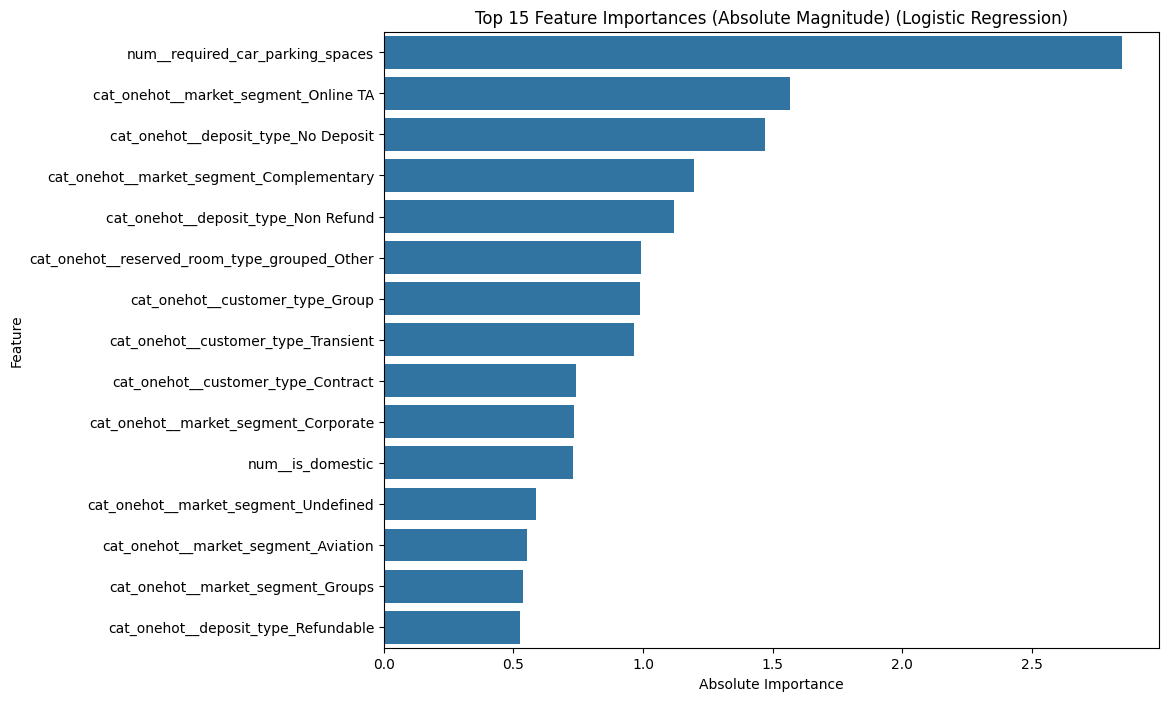


--- Nilai Feature Importance Eksak (Top 15 - Original Signed Coefficients) ---
num__required_car_parking_spaces               -2.847779
cat_onehot__market_segment_Online TA            1.567550
cat_onehot__deposit_type_No Deposit            -1.470535
cat_onehot__market_segment_Complementary       -1.195854
cat_onehot__deposit_type_Non Refund             1.120333
cat_onehot__reserved_room_type_grouped_Other    0.992885
cat_onehot__customer_type_Group                -0.988939
cat_onehot__customer_type_Transient             0.964742
cat_onehot__customer_type_Contract             -0.742316
cat_onehot__market_segment_Corporate           -0.734691
num__is_domestic                                0.730925
cat_onehot__market_segment_Undefined            0.587168
cat_onehot__market_segment_Aviation            -0.552874
cat_onehot__market_segment_Groups              -0.536216
cat_onehot__deposit_type_Refundable            -0.525118
dtype: float64

--- Interpretasi Bisnis Feature Importance ---
Fi

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Asumsi final_pipeline, preprocessor, X_train, y_train, X_test, y_test, best_model_name
# serta numerical_features, country_features, other_categorical_features
# sudah didefinisikan dan tersedia dari sel-sel sebelumnya.

# Dapatkan feature importance dari model terbaik
# Classifier dalam final_pipeline adalah model terbaik yang sudah dilatih

# Get feature names from the *fitted* preprocessor within the final_pipeline
fitted_preprocessor_from_pipeline = final_pipeline.named_steps['preprocessor']
preprocessed_feature_names = fitted_preprocessor_from_pipeline.get_feature_names_out()

# Access the trained classifier from the pipeline for feature importances
final_classifier = final_pipeline.named_steps['classifier']

# Handle different ways models store feature importances
if hasattr(final_classifier, 'feature_importances_'):
    feature_importances = pd.Series(final_classifier.feature_importances_, index=preprocessed_feature_names)
elif hasattr(final_classifier, 'coef_'):
    # For linear models, coef_ is used (need to handle multi-class if applicable, here binary)
    feature_importances = pd.Series(final_classifier.coef_[0], index=preprocessed_feature_names)
else:
    print("Model tidak memiliki atribut feature_importances_ atau coef_ yang dapat diakses.")
    feature_importances = pd.Series([]) # Empty series if no importance can be extracted

# Urutkan fitur berdasarkan kepentingannya jika ada
if not feature_importances.empty:
    # For Logistic Regression, coefficients can be negative, indicating inverse relationship.
    # For importance, we usually care about the absolute magnitude.
    feature_importances_to_plot = feature_importances.abs().sort_values(ascending=False)

    plt.figure(figsize=(10, 8))
    sns.barplot(x=feature_importances_to_plot.head(15).values, y=feature_importances_to_plot.head(15).index)
    plt.title(f'Top 15 Feature Importances (Absolute Magnitude) ({best_model_name})')
    plt.xlabel('Absolute Importance')
    plt.ylabel('Feature')
    plt.show()

    print("\n--- Nilai Feature Importance Eksak (Top 15 - Original Signed Coefficients) ---")
    # Display the original signed coefficients for top features by magnitude
    display_signed_importance = feature_importances.loc[feature_importances_to_plot.head(15).index]
    print(display_signed_importance)

else:
    print("Tidak dapat menampilkan feature importance karena tidak ditemukan.")

print("\n--- Interpretasi Bisnis Feature Importance ---")
print("Fitur dengan nilai importance yang lebih tinggi memiliki dampak yang lebih besar dalam memprediksi apakah pemesanan akan dibatalkan atau tidak.")
print("Contoh: koefisien positif pada 'deposit_type_Non Refund' menunjukkan tipe deposit ini")
print("justru menaikkan peluang pembatalan (89,2% booking Non Refund berakhir dibatalkan).")
print("Fitur terkait 'country' juga bisa signifikan, menunjukkan bahwa perilaku pembatalan bervariasi antar negara.")

### Penjelasan Hasil dalam Bahasa Bisnis:

Dari hasil _feature importance_ di atas, kita dapat mengidentifikasi beberapa faktor kunci yang sangat memengaruhi probabilitas pembatalan pemesanan hotel. Penting untuk diingat bahwa untuk model Regresi Logistik, _feature importance_ direpresentasikan oleh koefisiennya. Koefisien positif menunjukkan bahwa peningkatan nilai fitur tersebut meningkatkan probabilitas pembatalan, sedangkan koefisien negatif menurunkannya.

Berikut adalah fitur-fitur teratas yang paling berpengaruh berdasarkan **magnitudo absolut koefisien**:

*   **`num__required_car_parking_spaces`**: Fitur ini memiliki koefisien negatif yang paling signifikan (sekitar -2.85). Ini menunjukkan bahwa jika pelanggan membutuhkan tempat parkir (nilai > 0), probabilitas pembatalan justru **menurun secara drastis**. Ini bisa mengindikasikan komitmen yang lebih tinggi atau kebutuhan khusus yang membuat pembatalan kurang memungkinkan.

*   **`cat_onehot__market_segment_Online TA`**: Segmen pasar 'Online TA' menunjukkan koefisien positif yang kuat (sekitar 1.57). Pelanggan yang memesan melalui agen perjalanan *online* memiliki probabilitas pembatalan yang lebih tinggi dibandingkan segmen pasar lain. Ini mungkin terkait dengan fleksibilitas pembatalan yang ditawarkan oleh OTA atau perilaku pencarian pelanggan.

*   **`cat_onehot__deposit_type_No Deposit`**: Fitur ini memiliki koefisien negatif yang signifikan (sekitar -1.47). Ini menunjukkan bahwa pemesanan dengan `No Deposit` memiliki probabilitas pembatalan yang **lebih rendah**. Ini mungkin berlawanan dengan intuisi awal, tetapi bisa jadi segmen yang memilih 'No Deposit' juga memiliki karakteristik lain yang membuat mereka lebih berkomitmen atau hotel memiliki kebijakan yang berbeda untuk tipe deposit ini. Perlu investigasi lebih lanjut.

*   **`cat_onehot__market_segment_Complementary`**: Segmen 'Complementary' menunjukkan koefisien negatif yang kuat (sekitar -1.20). Ini berarti pemesanan dari segmen ini cenderung memiliki probabilitas pembatalan yang **jauh lebih rendah**, kemungkinan karena ini adalah pemesanan yang tidak dibayar penuh atau gratis, sehingga memiliki tujuan yang lebih pasti.

*   **`cat_onehot__deposit_type_Non Refund`**: Koefisien positif yang kuat (sekitar 1.12) menunjukkan bahwa pemesanan dengan tipe deposit `Non Refund` justru **meningkatkan peluang pembatalan**. Ini adalah anomali yang signifikan; intuisi seharusnya mengatakan sebaliknya. Analisis bivariat sebelumnya (jika ada dan menunjukkan hal yang sama) akan mendukung ini. Ini mungkin mengindikasikan bahwa tipe deposit `Non Refund` terkait dengan penawaran harga sangat murah yang menarik pemesan spekulatif, atau diterapkan pada segmen yang memang sudah berisiko tinggi dan tetap membatalkan meski kehilangan deposit.

*   **`cat_onehot__reserved_room_type_grouped_Other`**: Fitur ini memiliki koefisien positif yang signifikan (sekitar 0.99). Ini mengindikasikan bahwa pemesanan dengan tipe kamar yang dikelompokkan ke dalam kategori `Other` (yaitu, tipe kamar dengan frekuensi rendah) memiliki probabilitas pembatalan yang **lebih tinggi** dibandingkan dengan tipe kamar lainnya.

*   **`cat_onehot__customer_type_Group`**: Tipe pelanggan 'Group' memiliki koefisien negatif yang kuat (sekitar -0.99). Ini menunjukkan bahwa pemesanan oleh 'Group' cenderung memiliki probabilitas pembatalan yang **lebih rendah**.

*   **`cat_onehot__customer_type_Transient`**: Jenis pelanggan 'Transient' (individu tanpa kontrak khusus) memiliki koefisien positif (sekitar 0.96). Ini menunjukkan bahwa pelanggan tipe ini cenderung memiliki probabilitas pembatalan yang **lebih tinggi** dibandingkan tipe pelanggan lain, mungkin karena kurangnya ikatan kontraktual.

*   **`num__is_domestic`**: Fitur ini memiliki koefisien positif (sekitar 0.73). Ini menunjukkan bahwa pemesanan dari negara domestik (PRT) memiliki probabilitas pembatalan yang **lebih tinggi** dibandingkan pemesanan internasional. Ini bisa terkait dengan kemudahan pembatalan atau kebijakan yang berbeda untuk warga domestik.

*   **`num__has_previous_cancellations`**: Fitur hasil _feature engineering_ ini (apakah ada riwayat pembatalan sebelumnya) memiliki koefisien positif (sekitar 0.31). Ini menegaskan bahwa riwayat pembatalan adalah prediktor kuat untuk pembatalan di masa depan.

*   **`num__booking_changes`**: Menariknya, `booking_changes` memiliki koefisien negatif (sekitar -0.27). Ini menunjukkan bahwa semakin banyak perubahan yang dilakukan pada pemesanan, semakin *rendah* probabilitas pembatalannya. Hal ini mungkin karena pelanggan yang melakukan perubahan cenderung lebih berkomitmen pada pemesanannya setelah penyesuaian dilakukan, atau mereka tidak akan melakukan perubahan jika mereka berniat membatalkan.


### Hindari Menyimpulkan Hubungan Sebab-Akibat:

Penting untuk diingat bahwa _feature importance_ menunjukkan korelasi atau asosiasi yang kuat, bukan hubungan sebab-akibat langsung. Misalnya, tingginya _importance_ `deposit_type_Non Refund` menunjukkan bahwa tipe deposit ini sangat berkorelasi dengan probabilitas pembatalan. Namun, ini bukanlah berarti deposit *non-refundable* 'menyebabkan' pembatalan. Sebaliknya, ini menunjukkan pola di data kita di mana jenis pemesanan ini sangat sering dibatalkan, mungkin karena faktor-faktor lain yang tidak kita amati secara langsung.

# 10. Rekomendasi Bisnis

Berdasarkan model prediksi pembatalan pemesanan hotel dan analisis _feature importance_, berikut adalah rekomendasi bisnis untuk membantu hotel mengurangi tingkat pembatalan dan meningkatkan manajemen pendapatan.

### Prioritisasi Kontak oleh Tim Intervensi

Tim intervensi (misalnya, tim _customer service_ atau _revenue management_) memiliki kapasitas terbatas, sehingga prioritisasi sangat penting. Model dapat menghasilkan probabilitas pembatalan untuk setiap pemesanan. Prioritas intervensi dapat ditentukan sebagai berikut:

1.  **Prioritas Sangat Tinggi (High-Risk)**: Pemesanan dengan probabilitas pembatalan tertinggi (misalnya, probabilitas > 0.7 atau 0.8). Ini adalah pemesanan yang paling mungkin dibatalkan dan memiliki potensi kerugian terbesar jika tidak dicegah. Tim harus segera menghubungi pelanggan ini.
2.  **Prioritas Tinggi (Medium-High Risk)**: Pemesanan dengan probabilitas pembatalan menengah (misalnya, probabilitas antara 0.4 - 0.7). Pemesanan ini juga membutuhkan perhatian, tetapi mungkin dengan sumber daya yang lebih terukur atau intervensi yang lebih otomatis (misalnya, email penawaran otomatis).
3.  **Prioritas Rendah (Low-Risk)**: Pemesanan dengan probabilitas pembatalan rendah (probabilitas < 0.4). Pemesanan ini tidak memerlukan intervensi proaktif kecuali ada perubahan signifikan pada parameter pemesanan mereka.

Pemeringkatan ini memungkinkan hotel untuk mengalokasikan sumber daya secara efisien dan fokus pada pemesanan yang paling berisiko.

### Bentuk Intervensi untuk Booking Berisiko Tinggi

Untuk pemesanan yang diprediksi berisiko tinggi dibatalkan, intervensi dapat disesuaikan berdasarkan profil pelanggan dan tingkat risiko:

1.  **Personalisasi Komunikasi**: Tim dapat menghubungi pelanggan secara personal melalui telepon atau email untuk menanyakan apakah ada masalah dengan pemesanan mereka. Ini memberikan kesempatan untuk menyelesaikan kekhawatiran dan membangun hubungan.
2.  **Penawaran Insentif Bertarget**: Berikan insentif kecil yang menarik untuk mempertahankan pemesanan. Contohnya:
    *   _Upgrade_ kamar gratis (jika tersedia).
    *   Diskon kecil untuk fasilitas hotel (spa, restoran).
    *   Penawaran sarapan gratis.
    *   Fleksibilitas tambahan (misalnya, perubahan tanggal tanpa biaya jika masih dalam batas waktu tertentu).
3.  **Konfirmasi Detail dan Persyaratan**: Pastikan pelanggan memahami semua detail pemesanan, termasuk kebijakan pembatalan dan biaya. Terkadang pembatalan terjadi karena miskomunikasi.
4.  **Tindak Lanjut Otomatis**: Untuk volume pemesanan berisiko tinggi yang tidak dapat ditangani secara personal, sistem otomatis dapat mengirimkan email atau notifikasi dengan penawaran standar atau pengingat manfaat pemesanan.

### Bahas Risiko Implementasi dan Monitoring Performa Model

Implementasi model _machine learning_ dalam operasional bisnis memiliki risiko yang perlu dikelola:

1.  **Risiko _False Positive_ yang Tinggi**: Jika _threshold_ terlalu rendah, tim intervensi akan kelebihan beban dengan pemesanan yang sebenarnya tidak akan dibatalkan, menyebabkan pemborosan sumber daya dan potensi iritasi pelanggan.
2.  **Risiko _False Negative_ yang Tinggi**: Jika _threshold_ terlalu tinggi, hotel akan kehilangan banyak potensi pembatalan, yang berarti hilangnya pendapatan signifikan.
3.  **Perubahan Perilaku Pelanggan**: Pola pembatalan dapat berubah seiring waktu (musiman, tren perjalanan baru, peristiwa global), membuat model menjadi usang. Model perlu dilatih ulang secara berkala.
4.  **Kualitas Data**: Ketergantungan pada kualitas data input. Jika ada masalah dengan data baru, performa model akan terpengaruh.
5.  **Penerimaan Tim**: Tim operasional perlu dilatih dan diyakinkan tentang manfaat model agar adopsi berjalan lancar.

**Monitoring Performa Model**:

*   **Monitoring Berkelanjutan**: Performa model (terutama `Recall`, `Precision`, dan `AUC-ROC`) harus dipantau secara berkala pada data baru yang belum pernah dilihat model.
*   **Deteksi _Data Drift_**: Pantau distribusi fitur input. Jika distribusi fitur berubah secara signifikan (_data drift_), ini bisa mengindikasikan model perlu dilatih ulang.
*   **Analisis Dampak Bisnis**: Lacak dampak aktual dari intervensi yang direkomendasikan model. Apakah jumlah pembatalan berkurang? Apakah pendapatan meningkat? Ini adalah bukti nyata keberhasilan model.
*   **_A/B Testing_**: Lakukan _A/B testing_ untuk membandingkan kelompok yang menerima intervensi berdasarkan model dengan kelompok kontrol. Ini dapat secara empiris menunjukkan nilai tambah model.

### Berikan Saran Pengembangan Data Berikutnya

Untuk meningkatkan model di masa mendatang, beberapa pengembangan data dapat diusulkan:

1.  **Data Eksternal**: Integrasikan data eksternal yang relevan, seperti:
    *   **Peristiwa Lokal/Regional**: Kalender acara besar, konferensi, konser yang dapat memengaruhi permintaan.
    *   **Cuaca**: Prediksi cuaca di lokasi hotel.
    *   **Ulasan Pelanggan/Sentimen Media Sosial**: Analisis sentimen terhadap hotel atau destinasi.
    *   **Data Kompetitor**: Harga dan ketersediaan kamar di hotel pesaing (jika memungkinkan).
2.  **Data Historis yang Lebih Granular**: Jika tersedia, tambahkan data historis tentang:
    *   **Harga rata-rata kamar (ADR)** pada saat pemesanan dan perubahan harga setelahnya.
    *   **Ketersediaan kamar** pada saat pemesanan dan jumlah kamar yang tersisa.
    *   **Durasi menginap** dan jumlah tamu per kamar.
    *   **Saluran distribusi** yang lebih detail (misalnya, nama OTA spesifik).
3.  **Data Profil Pelanggan**: Jika diizinkan oleh regulasi privasi, tambahkan informasi demografis atau preferensi pelanggan yang dapat membantu membedakan pola pembatalan.
4.  **Umur Pemesanan (Lead Time)**: Buat fitur yang menghitung durasi dari tanggal pemesanan hingga tanggal kedatangan. Ini seringkali menjadi prediktor kuat.
5.  **Interaksi Fitur Lanjutan**: Eksplorasi interaksi antara fitur-fitur yang ada. Contoh:
    *   Interaksi antara `deposit_type` dan `customer_type`.
    *   Interaksi antara `market_segment` dan `country`.